# PCA + LSTM

In [ ]:
# Import packages
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# Level 1 data
ds_level1 = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-1_Future_prediction/train.csv",
    split="train"
)

# Convert to pandas DataFrame
df_level1 = ds_level1.to_pandas()
df_level1.head()

,Date,Tenor : 1; Maturity : 0.0833333333333333,Tenor : 2; Maturity : 0.0833333333333333,Tenor : 3; Maturity : 0.0833333333333333,Tenor : 4; Maturity : 0.0833333333333333,Tenor : 5; Maturity : 0.0833333333333333,Tenor : 6; Maturity : 0.0833333333333333,Tenor : 7; Maturity : 0.0833333333333333,Tenor : 8; Maturity : 0.0833333333333333,Tenor : 9; Maturity : 0.0833333333333333,...,Tenor : 5; Maturity : 30,Tenor : 6; Maturity : 30,Tenor : 7; Maturity : 30,Tenor : 8; Maturity : 30,Tenor : 9; Maturity : 30,Tenor : 10; Maturity : 30,Tenor : 15; Maturity : 30,Tenor : 20; Maturity : 30,Tenor : 25; Maturity : 30,Tenor : 30; Maturity : 30
0,01/01/2050,0.028565,0.038700,0.040127,0.040762,0.040466,0.038953,0.037553,0.036768,0.036646,...,0.331053,0.329056,0.330997,0.324676,0.325758,0.322393,0.345859,0.359162,0.346670,0.337670
1,02/01/2050,0.029334,0.039499,0.040982,0.041638,0.041336,0.039815,0.038397,0.037631,0.037504,...,0.336319,0.334434,0.336568,0.330244,0.331462,0.328144,0.351816,0.365197,0.350993,0.340822
2,03/01/2050,0.028696,0.038816,0.040328,0.041042,0.040804,0.039329,0.037968,0.037216,0.037107,...,0.333634,0.331707,0.333800,0.327487,0.328710,0.325436,0.348915,0.362236,0.348652,0.339027
3,05/01/2050,0.030854,0.041536,0.043035,0.043605,0.043241,0.041556,0.039977,0.039167,0.038968,...,0.336884,0.335106,0.337548,0.331279,0.332811,0.329771,0.353246,0.366100,0.351404,0.340465
4,06/01/2050,0.030406,0.041174,0.042681,0.043266,0.042937,0.041253,0.039685,0.038867,0.038667,...,0.333249,0.331426,0.333830,0.327580,0.329123,0.326146,0.349390,0.362048,0.348331,0.338022


In [3]:
# -------------------------------------------------
# 1. Prepare Data
# -------------------------------------------------

df = df_level1.copy()

# Ensure correct date ordering
df["Date"] = pd.to_datetime(df["Date"], format='%d/%m/%Y')
df = df.sort_values("Date").reset_index(drop=True)

# Drop Date column
price_df = df.drop(columns=["Date"])

prices = price_df.values  # shape (T, 224)

# Log transform
log_prices = np.log(prices)

# -------------------------------------------------
# 2. Train / Validation Split (chronological)
# -------------------------------------------------

T = len(log_prices)

train_data = log_prices[:int(T * 0.75), :]
val_data = log_prices[int(T * 0.75):, :]

In [4]:
# -------------------------------------------------
# 3. Scale (fit only on training)
# -------------------------------------------------

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)

In [5]:
# -------------------------------------------------
# 4. PCA (fit only on training)
# -------------------------------------------------

K = 5
pca = PCA(n_components=K)

train_factors = pca.fit_transform(train_scaled)
val_factors = pca.transform(val_scaled)

In [6]:
# -------------------------------------------------
# 5. Create Windows
# -------------------------------------------------

WINDOW = 60
HORIZON = 6

def create_windows(data):
    X, Y = [], []
    for t in range(WINDOW, len(data) - HORIZON):
        X.append(data[t-WINDOW:t])
        Y.append(data[t:t+HORIZON])
    return np.array(X), np.array(Y)

X_train, Y_train = create_windows(train_factors)
X_val, Y_val = create_windows(val_factors)

X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
Y_val = torch.tensor(Y_val, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=32,
    shuffle=False
)

val_loader = DataLoader(
    TensorDataset(X_val, Y_val),
    batch_size=32,
    shuffle=False
)

In [7]:
# -------------------------------------------------
# 6. Model
# -------------------------------------------------

class PCA_LSTM(nn.Module):
    def __init__(self, k, hidden=32, layers=2, horizon=6):
        super().__init__()
        self.lstm = nn.LSTM(k, hidden, layers, batch_first=True)
        self.fc = nn.Linear(hidden, k * horizon)
        self.horizon = horizon
        self.k = k

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.view(-1, self.horizon, self.k)

model = PCA_LSTM(K)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [8]:
# -------------------------------------------------
# 7. Training with Early Stopping
# -------------------------------------------------

EPOCHS = 200
PATIENCE = 15

best_val_loss = np.inf
patience_counter = 0

for epoch in range(EPOCHS):

    # ---- Train ----
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---- Validate ----
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            loss = criterion(pred, yb)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch} | Train {train_loss:.6f} | Val {val_loss:.6f}")

    # ---- Early Stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

# Load best model
model.load_state_dict(torch.load("best_model.pt"))

Epoch 0 | Train 44.654222 | Val 47.994060
Epoch 1 | Train 44.405784 | Val 47.720828
Epoch 2 | Train 44.111820 | Val 47.369463
Epoch 3 | Train 43.666624 | Val 46.883937
Epoch 4 | Train 42.965776 | Val 46.257743
Epoch 5 | Train 42.011663 | Val 45.552808
Epoch 6 | Train 40.949187 | Val 44.825332
Epoch 7 | Train 39.879933 | Val 44.099676
Epoch 8 | Train 38.827002 | Val 43.401944
Epoch 9 | Train 37.781602 | Val 42.703973
Epoch 10 | Train 36.738344 | Val 41.975903
Epoch 11 | Train 35.693184 | Val 41.229559
Epoch 12 | Train 34.692254 | Val 40.419527
Epoch 13 | Train 33.720218 | Val 39.658174
Epoch 14 | Train 32.774389 | Val 38.813561
Epoch 15 | Train 31.828548 | Val 38.051999
Epoch 16 | Train 30.913888 | Val 37.147508
Epoch 17 | Train 30.011818 | Val 36.325891
Epoch 18 | Train 29.164594 | Val 35.517738
Epoch 19 | Train 28.296881 | Val 34.778829
Epoch 20 | Train 27.497264 | Val 33.760192
Epoch 21 | Train 26.786271 | Val 33.062448
Epoch 22 | Train 26.118568 | Val 32.046893
Epoch 23 | Train 25.4

<All keys matched successfully>

In [9]:
# -------------------------------------------------
# Helper: reconstruct prices from factors
# -------------------------------------------------

def reconstruct_prices(factors_pred):
    """
    factors_pred: shape (K,) or (H, K)
    """

    factors_pred = np.atleast_2d(factors_pred)  # ensures 2D

    # inverse PCA
    log_scaled = pca.inverse_transform(factors_pred)

    # inverse scaling
    log_prices = scaler.inverse_transform(log_scaled)

    # back to price
    prices = np.exp(log_prices)

    return prices

def compute_surface_metrics(model, loader, eps=1e-8):
    """
    Returns RMSE and MAPE (in price space)
    """

    model.eval()
    mse_list = []
    mape_list = []

    with torch.no_grad():
        for xb, yb in loader:

            pred_factors = model(xb).numpy()   # (B, H, K)
            true_factors = yb.numpy()

            B, H, K = pred_factors.shape

            pred_factors = pred_factors.reshape(-1, K)
            true_factors = true_factors.reshape(-1, K)

            pred_prices = reconstruct_prices(pred_factors)
            true_prices = reconstruct_prices(true_factors)

            # RMSE
            mse = np.mean((pred_prices - true_prices)**2)
            mse_list.append(mse)

            # MAPE (avoid division by zero)
            mape = np.mean(
                np.abs((pred_prices - true_prices) /
                       (true_prices + eps))
            )
            mape_list.append(mape)

    rmse = np.sqrt(np.mean(mse_list))
    mape = 100 * np.mean(mape_list)

    return rmse, mape

train_rmse, train_mape = compute_surface_metrics(model, train_loader)
val_rmse, val_mape = compute_surface_metrics(model, val_loader)

print(f"Train RMSE: {train_rmse:.6f}")
print(f"Train MAPE: {train_mape:.4f}%")

print(f"Validation RMSE: {val_rmse:.6f}")
print(f"Validation MAPE: {val_mape:.4f}%")

Train RMSE: 0.011005
Train MAPE: 3.7193%
Validation RMSE: 0.011407
Validation MAPE: 5.3721%


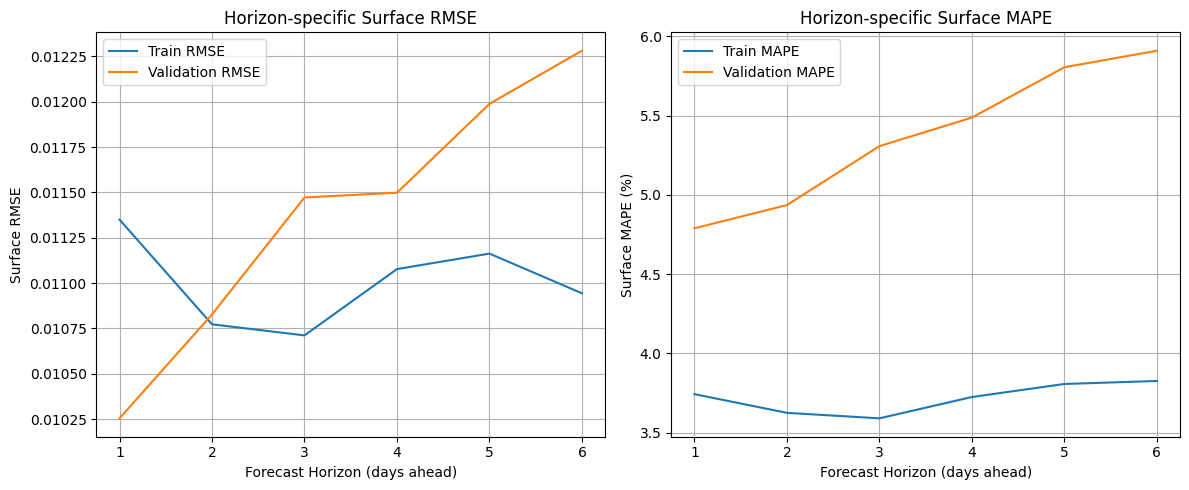

In [10]:
def compute_horizon_metrics(model, loader, eps=1e-8):
    """
    Compute RMSE and MAPE for each horizon step (1..HORIZON)
    Returns arrays of shape (HORIZON,)
    """

    model.eval()
    H = None
    rmse_list = []
    mape_list = []

    with torch.no_grad():
        for xb, yb in loader:
            pred_factors = model(xb).numpy()   # (B, H, K)
            true_factors = yb.numpy()           # (B, H, K)

            if H is None:
                H = pred_factors.shape[1]

            B = pred_factors.shape[0]

            for h in range(H):
                pred_h = pred_factors[:, h, :].reshape(-1, pred_factors.shape[2])
                true_h = true_factors[:, h, :].reshape(-1, pred_factors.shape[2])

                pred_prices = reconstruct_prices(pred_h)
                true_prices = reconstruct_prices(true_h)

                mse = np.mean((pred_prices - true_prices)**2)
                rmse_list.append((h, mse))

                mape = np.mean(np.abs((pred_prices - true_prices)/(true_prices + eps)))
                mape_list.append((h, mape))

    # Aggregate per horizon
    rmse_per_h = [np.sqrt(np.mean([m for (hh, m) in rmse_list if hh==h])) for h in range(H)]
    mape_per_h = [100*np.mean([m for (hh, m) in mape_list if hh==h]) for h in range(H)]

    return np.array(rmse_per_h), np.array(mape_per_h)

train_rmse_h, train_mape_h = compute_horizon_metrics(model, train_loader)
val_rmse_h, val_mape_h = compute_horizon_metrics(model, val_loader)

horizon = np.arange(1, len(train_rmse_h)+1)

plt.figure(figsize=(12,5))

# RMSE
plt.subplot(1,2,1)
plt.plot(horizon, train_rmse_h, label="Train RMSE")
plt.plot(horizon, val_rmse_h, label="Validation RMSE")
plt.xlabel("Forecast Horizon (days ahead)")
plt.ylabel("Surface RMSE")
plt.title("Horizon-specific Surface RMSE")
plt.legend()
plt.grid(True)

# MAPE
plt.subplot(1,2,2)
plt.plot(horizon, train_mape_h, label="Train MAPE")
plt.plot(horizon, val_mape_h, label="Validation MAPE")
plt.xlabel("Forecast Horizon (days ahead)")
plt.ylabel("Surface MAPE (%)")
plt.title("Horizon-specific Surface MAPE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ConvLSTM

In [156]:
# Extract Tenor and Maturity from column names
def parse_col(col):
    tenor = float(col.split(";")[0].split(":")[1])
    maturity = float(col.split(";")[1].split(":")[1])
    return tenor, maturity

col_info = [parse_col(c) for c in price_df.columns]
tenors = sorted(set(t for t, m in col_info))
maturities = sorted(set(m for t, m in col_info))

T = len(df)
H = len(maturities)
W = len(tenors)

# Build 3D tensor (T, H, W)
surface = np.zeros((T, H, W))

for j, (tenor, maturity) in enumerate(col_info):
    i_m = maturities.index(maturity)
    i_t = tenors.index(tenor)
    surface[:, i_m, i_t] = price_df.iloc[:, j].values

# Log transform
surface = np.log(surface)

In [157]:
split_idx = int(T * 0.75)

train_data = surface[:split_idx]
val_data = surface[split_idx:]

# Scale per node
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data.reshape(split_idx, -1))
val_scaled = scaler.transform(val_data.reshape(T - split_idx, -1))

train_scaled = train_scaled.reshape(split_idx, H, W)
val_scaled = val_scaled.reshape(T - split_idx, H, W)

In [ ]:
WINDOW = 30
HORIZON = 6

def create_windows(data):
    X, Y = [], []
    for t in range(WINDOW, len(data) - HORIZON):
        X.append(data[t-WINDOW:t])
        Y.append(data[t:t+HORIZON])
    return np.array(X), np.array(Y)

X_train, Y_train = create_windows(train_scaled)
X_val, Y_val = create_windows(val_scaled)

# Add channel dimension for ConvLSTM
X_train = torch.tensor(X_train[:, :, None, :, :], dtype=torch.float32)
Y_train = torch.tensor(Y_train[:, :, None, :, :], dtype=torch.float32)
X_val = torch.tensor(X_val[:, :, None, :, :], dtype=torch.float32)
Y_val = torch.tensor(Y_val[:, :, None, :, :], dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=16, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val, Y_val), batch_size=16, shuffle=False)

In [185]:
class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()
        padding = kernel_size // 2
        self.hidden_dim = hidden_dim
        self.conv = nn.Conv2d(
            input_dim + hidden_dim,
            4 * hidden_dim,
            kernel_size,
            padding=padding
        )

    def forward(self, x, h_prev, c_prev):
        combined = torch.cat([x, h_prev], dim=1)
        conv_out = self.conv(combined)
        cc_i, cc_f, cc_o, cc_g = torch.split(conv_out, self.hidden_dim, dim=1)

        i = torch.sigmoid(cc_i)
        f = torch.sigmoid(cc_f)
        o = torch.sigmoid(cc_o)
        g = torch.tanh(cc_g)

        c = f * c_prev + i * g
        h = o * torch.tanh(c)
        return h, c
    
class ConvLSTM(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=24, kernel_size=3, horizon=6):
        super().__init__()
        self.cell = ConvLSTMCell(input_dim, hidden_dim, kernel_size)
        self.output_conv = nn.Conv2d(hidden_dim, 1, kernel_size=1)
        self.horizon = horizon
        self.hidden_dim = hidden_dim

    def forward(self, x):
        B, T, C, H, W = x.shape

        h = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        c = torch.zeros(B, self.hidden_dim, H, W, device=x.device)

        # Encode past sequence
        for t in range(T):
            h, c = self.cell(x[:, t], h, c)

        outputs = []

        # Decode future sequence
        input_future = x[:, -1]  # last observed surface

        for _ in range(self.horizon):
            h, c = self.cell(input_future, h, c)
            out = self.output_conv(h)
            outputs.append(out.unsqueeze(1))
            input_future = out

        return torch.cat(outputs, dim=1)

In [186]:
model = ConvLSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

best_val = np.inf
patience = 10
counter = 0

for epoch in range(200):

    # Train
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validate
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch} | Train {train_loss:.6f} | Val {val_loss:.6f}")

    if val_loss < best_val:
        best_val = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_convlstm.pt")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

model.load_state_dict(torch.load("best_convlstm.pt"))

Epoch 0 | Train 0.716399 | Val 0.531593
Epoch 1 | Train 0.530496 | Val 0.388209
Epoch 2 | Train 0.328744 | Val 0.335831
Epoch 3 | Train 0.291228 | Val 0.359489
Epoch 4 | Train 0.251298 | Val 0.307542
Epoch 5 | Train 0.235936 | Val 0.262607
Epoch 6 | Train 0.239671 | Val 0.269916
Epoch 7 | Train 0.235259 | Val 0.246802
Epoch 8 | Train 0.218743 | Val 0.231005
Epoch 9 | Train 0.215370 | Val 0.223789
Epoch 10 | Train 0.218531 | Val 0.227529
Epoch 11 | Train 0.212954 | Val 0.224792
Epoch 12 | Train 0.203302 | Val 0.214447
Epoch 13 | Train 0.199979 | Val 0.213343
Epoch 14 | Train 0.199655 | Val 0.215140
Epoch 15 | Train 0.196311 | Val 0.215327
Epoch 16 | Train 0.191180 | Val 0.212940
Epoch 17 | Train 0.186820 | Val 0.210007
Epoch 18 | Train 0.185093 | Val 0.211075
Epoch 19 | Train 0.181598 | Val 0.209737
Epoch 20 | Train 0.180978 | Val 0.212820
Epoch 21 | Train 0.175672 | Val 0.206515
Epoch 22 | Train 0.175062 | Val 0.205184
Epoch 23 | Train 0.174650 | Val 0.208404
Epoch 24 | Train 0.172924 

<All keys matched successfully>

In [76]:
def reconstruct_prices_convlstm(pred_scaled):
    """
    pred_scaled: (N, H, W) in scaled log space
    """
    N = pred_scaled.shape[0]

    # reshape to 2D for scaler inverse
    pred_scaled_2d = pred_scaled.reshape(N, -1)

    log_prices = scaler.inverse_transform(pred_scaled_2d)
    log_prices = log_prices.reshape(N, H, W)

    return np.exp(log_prices)


def compute_surface_metrics_convlstm(model, loader, eps=1e-8):
    model.eval()

    mse_list = []
    mape_list = []

    with torch.no_grad():
        for xb, yb in loader:

            pred = model(xb).numpy()   # (B, HORIZON, 1, 16, 14)
            true = yb.numpy()

            B, HORIZON, _, HH, WW = pred.shape

            pred = pred.reshape(-1, HH, WW)
            true = true.reshape(-1, HH, WW)

            pred_prices = reconstruct_prices_convlstm(pred)
            true_prices = reconstruct_prices_convlstm(true)

            mse = np.mean((pred_prices - true_prices)**2)
            mape = np.mean(
                np.abs((pred_prices - true_prices) /
                       (true_prices + eps))
            )

            mse_list.append(mse)
            mape_list.append(mape)

    rmse = np.sqrt(np.mean(mse_list))
    mape = 100 * np.mean(mape_list)

    return rmse, mape

convlstm_train_rmse, convlstm_train_mape = compute_surface_metrics_convlstm(model, train_loader)
convlstm_val_rmse, convlstm_val_mape = compute_surface_metrics_convlstm(model, val_loader)

print("ConvLSTM Train RMSE:", convlstm_train_rmse)
print("ConvLSTM Train MAPE:", convlstm_train_mape)

print("ConvLSTM Val RMSE:", convlstm_val_rmse)
print("ConvLSTM Val MAPE:", convlstm_val_mape)

ConvLSTM Train RMSE: 0.0078810165
ConvLSTM Train MAPE: 2.647454
ConvLSTM Val RMSE: 0.0077051753
ConvLSTM Val MAPE: 3.2800875


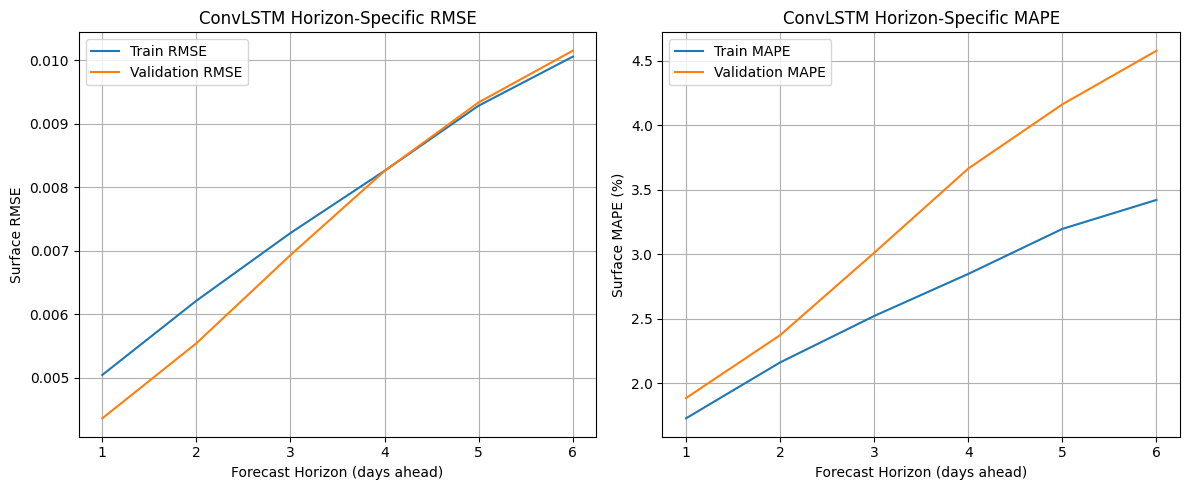

In [77]:
def compute_horizon_metrics_convlstm(model, loader, eps=1e-8):
    """
    Returns:
        rmse_per_h: (HORIZON,)
        mape_per_h: (HORIZON,)
    """

    model.eval()

    with torch.no_grad():

        # Collect errors per horizon
        horizon_mse = {}
        horizon_mape = {}

        for xb, yb in loader:

            pred = model(xb).numpy()     # (B, H, 1, 16, 14)
            true = yb.numpy()

            B, HORIZON, _, HH, WW = pred.shape

            for h in range(HORIZON):

                pred_h = pred[:, h, 0]   # (B, 16, 14)
                true_h = true[:, h, 0]

                # reshape to 2D for scaler
                pred_h = pred_h.reshape(-1, HH, WW)
                true_h = true_h.reshape(-1, HH, WW)

                pred_prices = reconstruct_prices_convlstm(pred_h)
                true_prices = reconstruct_prices_convlstm(true_h)

                mse = np.mean((pred_prices - true_prices)**2)
                mape = np.mean(
                    np.abs((pred_prices - true_prices) /
                           (true_prices + eps))
                )

                horizon_mse.setdefault(h, []).append(mse)
                horizon_mape.setdefault(h, []).append(mape)

        rmse_per_h = np.array([
            np.sqrt(np.mean(horizon_mse[h])) for h in range(HORIZON)
        ])

        mape_per_h = np.array([
            100 * np.mean(horizon_mape[h]) for h in range(HORIZON)
        ])

    return rmse_per_h, mape_per_h

convlstm_train_rmse_h, convlstm_train_mape_h = \
    compute_horizon_metrics_convlstm(model, train_loader)

convlstm_val_rmse_h, convlstm_val_mape_h = \
    compute_horizon_metrics_convlstm(model, val_loader)

import matplotlib.pyplot as plt
import numpy as np

horizon = np.arange(1, len(convlstm_train_rmse_h) + 1)

plt.figure(figsize=(12,5))

# RMSE
plt.subplot(1,2,1)
plt.plot(horizon, convlstm_train_rmse_h, label="Train RMSE")
plt.plot(horizon, convlstm_val_rmse_h, label="Validation RMSE")
plt.xlabel("Forecast Horizon (days ahead)")
plt.ylabel("Surface RMSE")
plt.title("ConvLSTM Horizon-Specific RMSE")
plt.legend()
plt.grid(True)

# MAPE
plt.subplot(1,2,2)
plt.plot(horizon, convlstm_train_mape_h, label="Train MAPE")
plt.plot(horizon, convlstm_val_mape_h, label="Validation MAPE")
plt.xlabel("Forecast Horizon (days ahead)")
plt.ylabel("Surface MAPE (%)")
plt.title("ConvLSTM Horizon-Specific MAPE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Reservoir Computing

In [162]:
# Train/Val split
split_idx = int(T * 0.75)

train_data = log_prices[:split_idx]
val_data = log_prices[split_idx:]

# Scale
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)

# PCA
K = 5
pca = PCA(n_components=K)

train_factors = pca.fit_transform(train_scaled)
val_factors = pca.transform(val_scaled)

In [163]:
WINDOW = 60
HORIZON = 6

def create_windows(data):
    X, Y = [], []
    for t in range(WINDOW, len(data) - HORIZON):
        X.append(data[t-WINDOW:t])
        Y.append(data[t:t+HORIZON].reshape(-1))
    return np.array(X), np.array(Y)

X_train, Y_train = create_windows(train_factors)
X_val, Y_val = create_windows(val_factors)

print(X_train.shape)  # (samples, 60, K)
print(Y_train.shape)  # (samples, 6*K)

(304, 60, 5)
(304, 30)


In [164]:
from numpy.linalg import inv

class ESN:
    def __init__(self, input_dim, reservoir_dim=150,
                 spectral_radius=0.9,
                 sparsity=0.1,
                 leak=0.3,
                 ridge=200):

        self.input_dim = input_dim
        self.reservoir_dim = reservoir_dim
        self.leak = leak
        self.ridge = ridge

        # Input weights
        self.Win = np.random.uniform(-1, 1, (reservoir_dim, input_dim))

        # Reservoir weights
        W = np.random.uniform(-1, 1, (reservoir_dim, reservoir_dim))
        mask = np.random.rand(*W.shape) < sparsity
        W *= mask

        # Scale spectral radius
        eigvals = np.linalg.eigvals(W)
        W *= spectral_radius / np.max(np.abs(eigvals))
        self.W = W

    def _run_reservoir(self, U):
        states = np.zeros((U.shape[0], self.reservoir_dim))

        for t in range(U.shape[0]):
            u = U[t]
            if t == 0:
                prev = np.zeros(self.reservoir_dim)
            else:
                prev = states[t-1]

            x = np.tanh(self.Win @ u + self.W @ prev)
            states[t] = (1 - self.leak)*prev + self.leak*x

        return states

    def fit(self, X, Y):

        # Collect final states for each window
        states = []

        for sample in X:
            reservoir_states = self._run_reservoir(sample)
            states.append(reservoir_states[-1])

        states = np.array(states)

        # Ridge regression
        I = np.eye(states.shape[1])
        self.Wout = inv(states.T @ states + self.ridge * I) @ states.T @ Y

    def predict(self, X):

        states = []

        for sample in X:
            reservoir_states = self._run_reservoir(sample)
            states.append(reservoir_states[-1])

        states = np.array(states)
        return states @ self.Wout

In [181]:
esn = ESN(
    input_dim=K,
    reservoir_dim=1000,
    spectral_radius=0.6,
    leak=0.3,
    ridge=10000
)

esn.fit(X_train, Y_train)

train_pred = esn.predict(X_train)
val_pred = esn.predict(X_val)

In [182]:
def reconstruct_from_esn(pred):
    pred = pred.reshape(-1, HORIZON, K)
    pred = pred.reshape(-1, K)

    log_scaled = pca.inverse_transform(pred)
    log_prices = scaler.inverse_transform(log_scaled)

    prices = np.exp(log_prices)
    return prices.reshape(-1, HORIZON, 224)

In [183]:
def compute_overall_metrics_esn(pred, true, eps=1e-8):

    pred_prices = reconstruct_from_esn(pred)
    true_prices = reconstruct_from_esn(true)

    mse = np.mean((pred_prices - true_prices)**2)
    rmse = np.sqrt(mse)

    mape = np.mean(
        np.abs((pred_prices - true_prices) /
               (true_prices + eps))
    ) * 100

    return rmse, mape


train_rmse, train_mape = compute_overall_metrics_esn(train_pred, Y_train)
val_rmse, val_mape = compute_overall_metrics_esn(val_pred, Y_val)

print("Train RMSE:", train_rmse)
print("Train MAPE:", train_mape)

print("Validation RMSE:", val_rmse)
print("Validation MAPE:", val_mape)

Train RMSE: 0.010342222093254404
Train MAPE: 3.6775839797307883
Validation RMSE: 0.009528046015412532
Validation MAPE: 3.9433263743821776


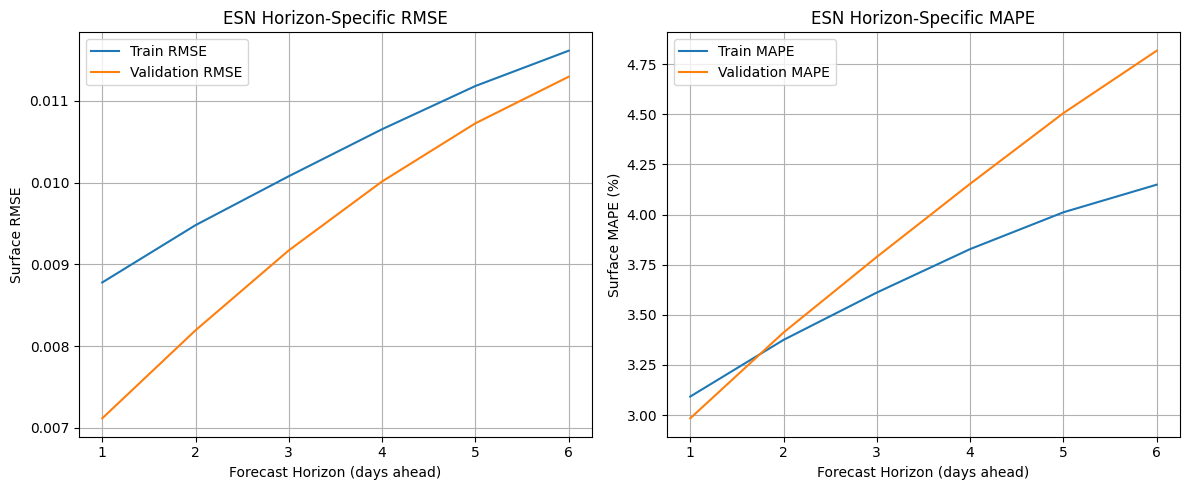

In [184]:
def compute_horizon_metrics_esn(pred, true, eps=1e-8):

    pred_prices = reconstruct_from_esn(pred)
    true_prices = reconstruct_from_esn(true)

    n_samples = pred_prices.shape[0]
    H = pred_prices.shape[1]

    rmse_h = []
    mape_h = []

    for h in range(H):

        pred_h = pred_prices[:, h, :]
        true_h = true_prices[:, h, :]

        mse = np.mean((pred_h - true_h)**2)
        rmse = np.sqrt(mse)

        mape = np.mean(
            np.abs((pred_h - true_h) /
                   (true_h + eps))
        ) * 100

        rmse_h.append(rmse)
        mape_h.append(mape)

    return np.array(rmse_h), np.array(mape_h)


train_rmse_h, train_mape_h = compute_horizon_metrics_esn(train_pred, Y_train)
val_rmse_h, val_mape_h = compute_horizon_metrics_esn(val_pred, Y_val)

import matplotlib.pyplot as plt
import numpy as np

horizon = np.arange(1, len(train_rmse_h) + 1)

plt.figure(figsize=(12,5))

# RMSE
plt.subplot(1,2,1)
plt.plot(horizon, train_rmse_h, label="Train RMSE")
plt.plot(horizon, val_rmse_h, label="Validation RMSE")
plt.xlabel("Forecast Horizon (days ahead)")
plt.ylabel("Surface RMSE")
plt.title("ESN Horizon-Specific RMSE")
plt.legend()
plt.grid(True)

# MAPE
plt.subplot(1,2,2)
plt.plot(horizon, train_mape_h, label="Train MAPE")
plt.plot(horizon, val_mape_h, label="Validation MAPE")
plt.xlabel("Forecast Horizon (days ahead)")
plt.ylabel("Surface MAPE (%)")
plt.title("ESN Horizon-Specific MAPE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Recursive Reservoir Predictions

(304, 60, 5)
(304, 6, 5)
Train RMSE: 0.012002449816445519
Train MAPE: 4.284927247229823
Validation RMSE: 0.009759015675957392
Validation MAPE: 4.183173733297465


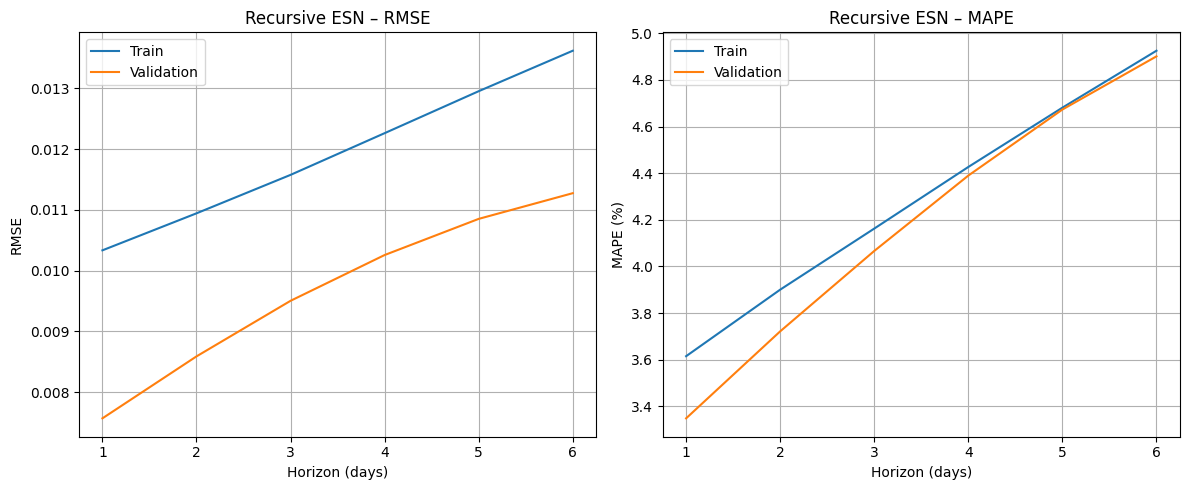

In [155]:
WINDOW = 60
HORIZON = 6

def create_recursive_windows(data):
    """
    Returns:
        X : (n_samples, WINDOW, K)
        Y : (n_samples, HORIZON, K)
    """
    X, Y = [], []

    for t in range(WINDOW, len(data) - HORIZON):
        X.append(data[t-WINDOW:t])
        Y.append(data[t:t+HORIZON])

    return np.array(X), np.array(Y)


X_train, Y_train = create_recursive_windows(train_factors)
X_val, Y_val = create_recursive_windows(val_factors)

print(X_train.shape)  # (n_samples, 60, K)
print(Y_train.shape)  # (n_samples, 6, K)

def create_one_step_data(data):
    X, Y = [], []
    for t in range(WINDOW, len(data) - 1):
        X.append(data[t-WINDOW:t])
        Y.append(data[t])
    return np.array(X), np.array(Y)

X_train_1, Y_train_1 = create_one_step_data(train_factors)

import numpy as np

class ESN:
    def __init__(self, input_dim, reservoir_dim=400,
                 spectral_radius=0.7,
                 sparsity=0.1,
                 leak=0.2,
                 ridge=10000):

        self.input_dim = input_dim
        self.reservoir_dim = reservoir_dim
        self.leak = leak
        self.ridge = ridge

        self.Win = np.random.uniform(-1, 1,
                                     (reservoir_dim, input_dim))

        W = np.random.uniform(-1, 1,
                              (reservoir_dim, reservoir_dim))

        mask = np.random.rand(*W.shape) < sparsity
        W *= mask

        eigvals = np.linalg.eigvals(W)
        W *= spectral_radius / np.max(np.abs(eigvals))

        self.W = W

    def run_reservoir(self, U, state=None):

        if state is None:
            state = np.zeros(self.reservoir_dim)

        for u in U:
            x = np.tanh(self.Win @ u + self.W @ state)
            state = (1 - self.leak)*state + self.leak*x

        return state

    def fit(self, X, Y):

        states = []

        for sample in X:
            final_state = self.run_reservoir(sample)
            states.append(final_state)

        states = np.array(states)

        I = np.eye(self.reservoir_dim)
        self.Wout = np.linalg.inv(
            states.T @ states + self.ridge * I
        ) @ states.T @ Y

    def predict_one(self, window):

        state = self.run_reservoir(window)
        return state @ self.Wout, state

esn = ESN(input_dim=K)
esn.fit(X_train_1, Y_train_1)

def recursive_forecast(esn, window, horizon=6):

    preds = []
    state = esn.run_reservoir(window)

    for _ in range(horizon):

        next_pred = state @ esn.Wout
        preds.append(next_pred)

        # update state using predicted value
        x = np.tanh(esn.Win @ next_pred + esn.W @ state)
        state = (1 - esn.leak)*state + esn.leak*x

    return np.array(preds)

def generate_predictions(esn, X, horizon=6):

    all_preds = []

    for window in X:
        preds = recursive_forecast(esn, window, horizon)
        all_preds.append(preds)

    return np.array(all_preds)


train_pred = generate_predictions(esn, X_train)
val_pred = generate_predictions(esn, X_val)

def reconstruct(pred):

    n_samples = pred.shape[0]

    pred_flat = pred.reshape(-1, K)

    log_scaled = pca.inverse_transform(pred_flat)
    log_prices = scaler.inverse_transform(log_scaled)
    prices = np.exp(log_prices)

    return prices.reshape(n_samples, HORIZON, -1)

def compute_overall_metrics(pred, true, eps=1e-8):

    pred_prices = reconstruct(pred)
    true_prices = reconstruct(true)

    mse = np.mean((pred_prices - true_prices)**2)
    rmse = np.sqrt(mse)

    mape = np.mean(
        np.abs((pred_prices - true_prices) /
               (true_prices + eps))
    ) * 100

    return rmse, mape


train_rmse, train_mape = compute_overall_metrics(train_pred, Y_train)
val_rmse, val_mape = compute_overall_metrics(val_pred, Y_val)

print("Train RMSE:", train_rmse)
print("Train MAPE:", train_mape)
print("Validation RMSE:", val_rmse)
print("Validation MAPE:", val_mape)

def compute_horizon_metrics(pred, true, eps=1e-8):

    pred_prices = reconstruct(pred)
    true_prices = reconstruct(true)

    rmse_h = []
    mape_h = []

    for h in range(HORIZON):

        pred_h = pred_prices[:, h, :]
        true_h = true_prices[:, h, :]

        mse = np.mean((pred_h - true_h)**2)
        rmse = np.sqrt(mse)

        mape = np.mean(
            np.abs((pred_h - true_h) /
                   (true_h + eps))
        ) * 100

        rmse_h.append(rmse)
        mape_h.append(mape)

    return np.array(rmse_h), np.array(mape_h)


train_rmse_h, train_mape_h = compute_horizon_metrics(train_pred, Y_train)
val_rmse_h, val_mape_h = compute_horizon_metrics(val_pred, Y_val)

import matplotlib.pyplot as plt
import numpy as np

horizon = np.arange(1, HORIZON + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(horizon, train_rmse_h, label="Train")
plt.plot(horizon, val_rmse_h, label="Validation")
plt.xlabel("Horizon (days)")
plt.ylabel("RMSE")
plt.title("Recursive ESN – RMSE")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(horizon, train_mape_h, label="Train")
plt.plot(horizon, val_mape_h, label="Validation")
plt.xlabel("Horizon (days)")
plt.ylabel("MAPE (%)")
plt.title("Recursive ESN – MAPE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Persistence

Persistence Train RMSE: 0.008228642807921684
Persistence Train MAPE: 2.7538170262165096
Persistence Validation RMSE: 0.0067103473852707755
Persistence Validation MAPE: 2.6472411895946593


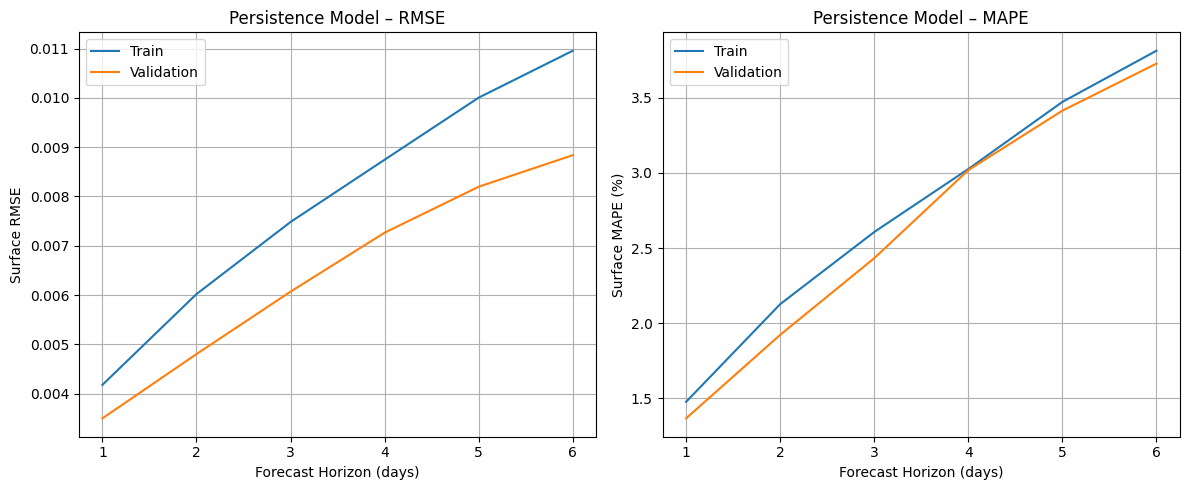

In [92]:
def persistence_forecast(X, horizon=6):
    """
    X: (n_samples, WINDOW, K)
    Returns:
        pred: (n_samples, HORIZON, K)
    """

    last_step = X[:, -1, :]           # (n_samples, K)

    # Repeat across horizon
    pred = np.repeat(
        last_step[:, np.newaxis, :],
        horizon,
        axis=1
    )

    return pred

train_pred_persist = persistence_forecast(X_train, HORIZON)
val_pred_persist   = persistence_forecast(X_val, HORIZON)

def reconstruct(pred):

    n_samples = pred.shape[0]

    pred_flat = pred.reshape(-1, K)

    log_scaled = pca.inverse_transform(pred_flat)
    log_prices = scaler.inverse_transform(log_scaled)
    prices = np.exp(log_prices)

    return prices.reshape(n_samples, HORIZON, -1)

def compute_overall_metrics(pred, true, eps=1e-8):

    pred_prices = reconstruct(pred)
    true_prices = reconstruct(true)

    mse = np.mean((pred_prices - true_prices) ** 2)
    rmse = np.sqrt(mse)

    mape = np.mean(
        np.abs((pred_prices - true_prices) /
               (true_prices + eps))
    ) * 100

    return rmse, mape


train_rmse_p, train_mape_p = compute_overall_metrics(
    train_pred_persist, Y_train
)

val_rmse_p, val_mape_p = compute_overall_metrics(
    val_pred_persist, Y_val
)

print("Persistence Train RMSE:", train_rmse_p)
print("Persistence Train MAPE:", train_mape_p)
print("Persistence Validation RMSE:", val_rmse_p)
print("Persistence Validation MAPE:", val_mape_p)

def compute_horizon_metrics(pred, true, eps=1e-8):

    pred_prices = reconstruct(pred)
    true_prices = reconstruct(true)

    rmse_h = []
    mape_h = []

    for h in range(HORIZON):

        pred_h = pred_prices[:, h, :]
        true_h = true_prices[:, h, :]

        mse = np.mean((pred_h - true_h) ** 2)
        rmse = np.sqrt(mse)

        mape = np.mean(
            np.abs((pred_h - true_h) /
                   (true_h + eps))
        ) * 100

        rmse_h.append(rmse)
        mape_h.append(mape)

    return np.array(rmse_h), np.array(mape_h)


train_rmse_h_p, train_mape_h_p = compute_horizon_metrics(
    train_pred_persist, Y_train
)

val_rmse_h_p, val_mape_h_p = compute_horizon_metrics(
    val_pred_persist, Y_val
)

import matplotlib.pyplot as plt
import numpy as np

horizon = np.arange(1, HORIZON + 1)

plt.figure(figsize=(12,5))

# RMSE
plt.subplot(1,2,1)
plt.plot(horizon, train_rmse_h_p, label="Train")
plt.plot(horizon, val_rmse_h_p, label="Validation")
plt.xlabel("Forecast Horizon (days)")
plt.ylabel("Surface RMSE")
plt.title("Persistence Model – RMSE")
plt.legend()
plt.grid(True)

# MAPE
plt.subplot(1,2,2)
plt.plot(horizon, train_mape_h_p, label="Train")
plt.plot(horizon, val_mape_h_p, label="Validation")
plt.xlabel("Forecast Horizon (days)")
plt.ylabel("Surface MAPE (%)")
plt.title("Persistence Model – MAPE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# QRC model

In [206]:
import numpy as np
import perceval as pcvl
from perceval.components import BS, PS
from perceval.backends import SLOSBackend
from perceval.algorithm import Sampler
from sklearn.linear_model import Ridge

# Train/Val split
split_idx = int(T * 0.75)

train_data = log_prices[:split_idx]
val_data = log_prices[split_idx:]

# Scale
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)

# PCA
K = 10
pca = PCA(n_components=K)

train_factors = pca.fit_transform(train_scaled)
val_factors = pca.transform(val_scaled)

# --------------------------------
# Generate Windows
# --------------------------------

WINDOW = 60
HORIZON = 6

X_train, Y_train = create_recursive_windows(train_factors)
X_val, Y_val = create_recursive_windows(val_factors)

print(X_train[0][0])

# --------------------------------
# Parameters
# --------------------------------

K = train_factors.shape[1]
print(K)
N_MODES = 10           # optical modes
RES_DEPTH = 3          # interferometer depth
HORIZON = 6
RIDGE_ALPHA = 1e-2

# --------------------------------
# Build Random Linear Optical Reservoir
# --------------------------------

def build_random_interferometer(n_modes, depth):
    circuit = pcvl.Circuit(n_modes)

    for _ in range(depth):
        for m in range(n_modes - 1):
            theta = np.random.uniform(0, 2*np.pi)
            phi = np.random.uniform(0, 2*np.pi)

            circuit.add((m, m+1), BS(theta))
            circuit.add(m, PS(phi))

    return circuit

circuit = build_random_interferometer(N_MODES, RES_DEPTH)

# Create local simulation backend
backend = SLOSBackend()

# Wrap circuit into processor
processor = pcvl.Processor(backend, N_MODES)
processor.add(0, circuit)

# Create sampler from processor
sampler = Sampler(processor)

# --------------------------------
# Quantum Reservoir State Update
# --------------------------------

def quantum_reservoir_step(input_vec, feedback_vec=None):

    if feedback_vec is None:
        feedback_vec = np.zeros_like(input_vec)

    combined = input_vec[:N_MODES] + 0.3 * feedback_vec
    combined = np.abs(combined)

    # Normalize
    combined = combined / (np.max(combined) + 1e-8)

    # Encode as small photon numbers (0,1,2)
    photons = [int(x * 2) for x in combined]

    # Pad if needed
    photons += [0] * (N_MODES - len(photons))

    state = pcvl.BasicState(photons)

# ---- THIS IS THE CRITICAL FIX ----
    processor.with_input(state)

    job = sampler.probs
    result = job()     # execute job

    prob_dist = result["results"]

    # Compute expected photon counts
    exp_counts = np.zeros(N_MODES)

    for output_state, prob in prob_dist.items():
        exp_counts += prob * np.array(list(output_state))

    return exp_counts

# --------------------------------
# Generate Reservoir States
# --------------------------------

def generate_states(X):
    states = []

    for window in X:
        print(len(states))
        feedback = np.zeros_like(window[0])
        reservoir_state = []

        for u in window:
            meas = quantum_reservoir_step(u, feedback)
            reservoir_state.append(meas)
            feedback = meas

        # Use last measured state
        states.append(reservoir_state[-1])

    return np.array(states)

# --------------------------------
# Train Quantum Reservoir Readout
# --------------------------------

X_train_states = generate_states(X_train)
X_val_states   = generate_states(X_val)

# Train to predict 1-step ahead factor
y_train = Y_train[:, 0, :]   # first step

readout = Ridge(alpha=RIDGE_ALPHA)
readout.fit(X_train_states, y_train)

# --------------------------------
# Recursive 6-Step Forecast
# --------------------------------

def recursive_predict(window):
    feedback = np.zeros(N_MODES)
    
    for u in window:
        meas = quantum_reservoir_step(u, feedback)
        feedback = meas

    preds = []
    current_input = window[-1]

    for _ in range(HORIZON):
        meas = quantum_reservoir_step(current_input, feedback)

        y_pred = readout.predict(meas.reshape(1, -1))[0]
        preds.append(y_pred)

        feedback = meas
        current_input = y_pred

    return np.array(preds)

# --------------------------------
# Predict
# --------------------------------

train_pred = np.array([recursive_predict(w) for w in X_train])
val_pred   = np.array([recursive_predict(w) for w in X_val])

# --------------------------------
# Reconstruction to Price Space
# --------------------------------

def reconstruct(pred):
    n, H, _ = pred.shape
    flat = pred.reshape(-1, K)
    log_scaled = pca.inverse_transform(flat)
    log_prices = scaler.inverse_transform(log_scaled)
    prices = np.exp(log_prices)
    return prices.reshape(n, H, -1)

def compute_metrics(pred, true):
    pred_p = reconstruct(pred)
    true_p = reconstruct(true)
    rmse = np.sqrt(np.mean((pred_p - true_p)**2))
    mape = np.mean(np.abs((pred_p - true_p) / (true_p + 1e-8))) * 100
    return rmse, mape

train_rmse, train_mape = compute_metrics(train_pred, Y_train)
val_rmse, val_mape     = compute_metrics(val_pred, Y_val)

print("Quantum Reservoir Train RMSE:", train_rmse, "MAPE:", train_mape)
print("Quantum Reservoir Val RMSE:", val_rmse, "MAPE:", val_mape)

[-2.45915165e+01  1.34506595e+00  9.30274523e-01  1.16607299e-02
 -3.63559480e-01 -4.10049170e-02 -1.71711001e-02 -1.49424254e-02
  3.13954024e-02 -3.28961369e-03]
10
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235

In [215]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge

# ============================================================
# 1. PCA WITH AUTOMATIC DIMENSION SELECTION
# ============================================================

scaler = StandardScaler()
log_scaled = scaler.fit_transform(log_prices)

pca_full = PCA()
pca_full.fit(log_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
K = np.argmax(cumvar >= 0.99) + 1
K = 5
print("Chosen PCA components K =", K)

pca = PCA(n_components=K)
factors = pca.fit_transform(log_scaled)

# ============================================================
# 2. TRAIN / VALIDATION SPLIT
# ============================================================

T = factors.shape[0]
split = int(0.8 * T)

train_factors = factors[:split]
val_factors   = factors[split:]

WINDOW  = 60
HORIZON = 6

def create_windows(data):
    X, Y = [], []
    for t in range(WINDOW, len(data) - HORIZON):
        X.append(data[t-WINDOW:t])
        Y.append(data[t:t+HORIZON])
    return np.array(X), np.array(Y)

X_train, Y_train = create_windows(train_factors)
X_val,   Y_val   = create_windows(val_factors)

# ============================================================
# 3. 20-MODE STABLE MULTIPHOTON RESERVOIR
# ============================================================

N_MODES = 20

# Contraction + scaling parameters
SPECTRAL_SCALE  = 0.6
INPUT_SCALE     = 1.
FEEDBACK_SCALE  = 0.5
RIDGE_ALPHA     = 100

# Random complex unitary (Haar-like)
def random_unitary(n):
    A = np.random.randn(n, n) + 1j*np.random.randn(n, n)
    Q, R = np.linalg.qr(A)
    return Q

U = random_unitary(N_MODES)

Win = np.random.randn(N_MODES, K) * 0.5
Wfb = np.random.randn(N_MODES, K) * 0.2

def reservoir_step(state, input_vec, feedback):
    # Contracted unitary evolution
    state = SPECTRAL_SCALE * (U @ state)

    # Add scaled input and feedback
    state += INPUT_SCALE * (Win @ input_vec)
    state += FEEDBACK_SCALE * (Wfb @ feedback)

    # Energy normalization (prevents explosion)
    norm = np.linalg.norm(state)
    if norm > 1:
        state = state / norm

    return state

def multiphoton_features(state):
    """
    Mimics multiphoton detection statistics.
    Use scaled nonlinear observables.
    """
    abs_state = np.abs(state)
    return np.concatenate([
        abs_state**2,
        0.1 * abs_state**4
    ])

# ============================================================
# 4. GENERATE RESERVOIR STATES (TEACHER FORCING)
# ============================================================

def generate_states(X):
    states = []

    for window in X:
        state = np.zeros(N_MODES, dtype=complex)
        feedback = np.zeros(K)

        for u in window:
            state = reservoir_step(state, u, feedback)
            feedback = u  # teacher forcing

        features = multiphoton_features(state)
        states.append(features)

    return np.array(states)

X_train_states = generate_states(X_train)
X_val_states   = generate_states(X_val)

# ============================================================
# 5. TRAIN READOUT (1-STEP AHEAD)
# ============================================================

y_train = Y_train[:, 0, :]

readout = Ridge(alpha=RIDGE_ALPHA)
readout.fit(X_train_states, y_train)

# ============================================================
# 6. RECURSIVE 6-STEP FORECAST
# ============================================================

def recursive_predict(window):
    state = np.zeros(N_MODES, dtype=complex)
    feedback = np.zeros(K)

    # Drive reservoir with history
    for u in window:
        state = reservoir_step(state, u, feedback)
        feedback = u

    preds = []
    current_input = window[-1]

    for _ in range(HORIZON):
        state = reservoir_step(state, current_input, feedback)
        features = multiphoton_features(state)

        y_pred = readout.predict(features.reshape(1, -1))[0]

        # Clip factors to avoid overflow in exp()
        y_pred = np.clip(y_pred, -10, 10)

        preds.append(y_pred)

        current_input = y_pred
        feedback = y_pred

    return np.array(preds)

train_pred = np.array([recursive_predict(w) for w in X_train])
val_pred   = np.array([recursive_predict(w) for w in X_val])

# ============================================================
# 7. RECONSTRUCT TO PRICE SPACE SAFELY
# ============================================================

def reconstruct(pred):
    n, H, _ = pred.shape

    flat = pred.reshape(-1, K)
    flat = np.clip(flat, -10, 10)

    log_scaled = pca.inverse_transform(flat)
    log_prices_rec = scaler.inverse_transform(log_scaled)

    # Safe exponentiation
    log_prices_rec = np.clip(log_prices_rec, -50, 50)
    prices = np.exp(log_prices_rec)

    return prices.reshape(n, H, -1)

def compute_metrics(pred, true):
    pred_p = reconstruct(pred)
    true_p = reconstruct(true)

    rmse = np.sqrt(np.mean((pred_p - true_p)**2))
    mape = np.mean(np.abs((pred_p - true_p) / (true_p + 1e-8))) * 100

    return rmse, mape

train_rmse, train_mape = compute_metrics(train_pred, Y_train)
val_rmse,   val_mape   = compute_metrics(val_pred, Y_val)

print("Stable Multiphoton Reservoir Train RMSE:", train_rmse, "MAPE:", train_mape)
print("Stable Multiphoton Reservoir Val   RMSE:", val_rmse,   "MAPE:", val_mape)

Chosen PCA components K = 5
Stable Multiphoton Reservoir Train RMSE: 0.014621354281664696 MAPE: 5.444387268041433
Stable Multiphoton Reservoir Val   RMSE: 0.018126043305989475 MAPE: 10.065161825048515


# Quantum + PCA + LSTM

In [17]:
import numpy as np
import perceval as pcvl
from perceval.backends import SLOSBackend
from perceval.algorithm import Sampler

class QuantumFeatureExtractor:
    def __init__(self, n_modes):
        self.n_modes = n_modes

        # Build a random interferometer
        self.circuit = pcvl.Circuit(n_modes)
        for m in range(n_modes - 1):
            theta = np.random.uniform(0, np.pi)
            phi   = np.random.uniform(0, 2*np.pi)
            self.circuit.add((m, m+1), pcvl.components.BS(theta))
            self.circuit.add(m, pcvl.components.PS(phi))

        # Processor & Sampler
        backend = SLOSBackend()
        self.processor = pcvl.Processor(backend, n_modes)
        self.processor.add(0, self.circuit)
        self.sampler = Sampler(self.processor)

    def encode(self, x):
        """
        Encode a K‑dim vector x into coherent amplitudes
        |alpha_i> per mode.
        """
        x_norm = x / (np.linalg.norm(x) + 1e-8)
        amps = x_norm * 2.0  # scale coherent amplitude
        return amps

    def extract(self, x):
        """
        x: shape (batch, K)
        Returns: quantum features (batch, n_modes)
        """
        feats = []
        for vec in x:
            # Suppose x is your PCA-reduced vector of size K
            amps = np.abs(vec) * 2  # scale to small photon numbers
            photons = np.round(amps).astype(int)
            state = pcvl.BasicState(photons.tolist())  # one state per mode
            self.processor.with_input(state)
            job = self.sampler.probs
            result = job()
            prob_dist = result["results"]
            # Compute expectation of photon count per mode
            features = np.zeros(self.n_modes)
            for out_state, prob in prob_dist.items():
                features += prob * np.array(list(out_state))
            feats.append(features)
        return np.array(feats)

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# PCA on log prices as before
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled   = scaler.transform(val_data)

K=10

pca = PCA(n_components=K)
train_factors = pca.fit_transform(train_scaled)
val_factors   = pca.transform(val_scaled)

# Create windows for factors
WINDOW = 60
HORIZON = 6

def create_windows(data):
    X, Y = [], []
    for t in range(WINDOW, len(data)-HORIZON):
        X.append(data[t-WINDOW:t])
        Y.append(data[t:t+HORIZON])
    return np.array(X), np.array(Y)

X_train, Y_train = create_windows(train_factors)
X_val,   Y_val   = create_windows(val_factors)

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# PCA on log prices as before
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled   = scaler.transform(val_data)

pca = PCA(n_components=K)
train_factors = pca.fit_transform(train_scaled)
val_factors   = pca.transform(val_scaled)

# Create windows for factors
WINDOW = 60
HORIZON = 6

def create_windows(data):
    X, Y = [], []
    for t in range(WINDOW, len(data)-HORIZON):
        X.append(data[t-WINDOW:t])
        Y.append(data[t:t+HORIZON])
    return np.array(X), np.array(Y)

X_train, Y_train = create_windows(train_factors)
X_val,   Y_val   = create_windows(val_factors)

In [20]:
import torch
import torch.nn as nn

n_modes = 10  # quantum modes

quantum_extractor = QuantumFeatureExtractor(n_modes)

class QuantumLSTM(nn.Module):
    def __init__(self, qdim, hidden=64, layers=2, horizon=6):
        super().__init__()
        self.lstm = nn.LSTM(qdim, hidden, layers, batch_first=True)
        self.fc = nn.Linear(hidden, qdim * horizon)
        self.horizon = horizon
        self.qdim = qdim

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.view(-1, self.horizon, self.qdim)


model = QuantumLSTM(n_modes)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
EPOCHS = 100
PATIENCE = 10
best_val = np.inf
patience = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for i in range(len(X_train)):
        # Extract quantum features for this sample
        print(i)
        qX = quantum_extractor.extract(X_train[i])
        qX = torch.tensor(qX, dtype=torch.float32).unsqueeze(0)

        y_true = torch.tensor(Y_train[i], dtype=torch.float32).unsqueeze(0)

        optimizer.zero_grad()
        pred = model(qX)
        loss = criterion(pred, y_true)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for i in range(len(X_val)):
            qX = quantum_extractor.extract(X_val[i])
            qX = torch.tensor(qX, dtype=torch.float32).unsqueeze(0)
            y_true = torch.tensor(Y_val[i], dtype=torch.float32).unsqueeze(0)
            pred = model(qX)
            val_loss += criterion(pred, y_true).item()

    val_loss /= len(X_val)
    print(f"Epoch {epoch} | Train {train_loss:.4f} | Val {val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "quantum_lstm.pt")
        patience = 0
    else:
        patience += 1
        if patience >= PATIENCE:
            print("Early stopping")
            break

model.load_state_dict(torch.load("quantum_lstm.pt"))

0


In [16]:
# -------------------------------------------------
# Imports
# -------------------------------------------------
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perceval imports
import perceval as pcvl
from perceval.backends import SLOSBackend
from perceval.algorithm import Sampler

# -------------------------------------------------
# 1. Load dataset
# -------------------------------------------------
df = df_level1.copy()
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
df = df.sort_values("Date").reset_index(drop=True)
price_df = df.drop(columns=["Date"])
prices = price_df.values
log_prices = np.log(prices)

# -------------------------------------------------
# 2. Train/Validation Split
# -------------------------------------------------
T = len(log_prices)
train_data = log_prices[:int(T*0.75), :]
val_data = log_prices[int(T*0.75):, :]

# -------------------------------------------------
# 3. Scale
# -------------------------------------------------
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)

# -------------------------------------------------
# 4. PCA
# -------------------------------------------------
K = 4  # number of components
pca = PCA(n_components=K)
train_factors = pca.fit_transform(train_scaled)
val_factors = pca.transform(val_scaled)

# -------------------------------------------------
# 5. Create windows
# -------------------------------------------------
WINDOW = 60
HORIZON = 6

def create_windows(data):
    X, Y = [], []
    for t in range(WINDOW, len(data) - HORIZON):
        X.append(data[t-WINDOW:t])
        Y.append(data[t:t+HORIZON])
    return np.array(X), np.array(Y)

X_train, Y_train = create_windows(train_factors)
X_val, Y_val = create_windows(val_factors)

# Convert to torch
X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
Y_val = torch.tensor(Y_val, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=8, shuffle=False)
val_loader   = DataLoader(TensorDataset(X_val, Y_val), batch_size=8, shuffle=False)

# -------------------------------------------------
# 6. Quantum Variational Layer
# -------------------------------------------------
class QuantumVariationalLayer:
    def __init__(self, n_modes):
        self.n_modes = n_modes
        self.circuit = pcvl.Circuit(n_modes)
        for i in range(n_modes-1):
            self.circuit.add((i, i+1), pcvl.components.BS(np.pi/4))
            self.circuit.add(i, pcvl.components.PS(np.pi/4))
        self.processor = pcvl.Processor(SLOSBackend(), n_modes)
        self.processor.add(0, self.circuit)
        self.sampler = Sampler(self.processor)

    def encode(self, x):
        amps = np.abs(x)
        photons = np.clip(np.round(amps), 0, 2).astype(int)
        return photons

    def forward(self, x_batch):
        feats = []
        for v in x_batch:
            state = pcvl.FockState(self.encode(v).tolist())
            self.processor.with_input(state)
            job = self.sampler.probs
            result = job()
            prob_dist = result["results"]
            qfeat = np.zeros(self.n_modes)
            for out, p in result.items():
                qfeat += p * np.array(list(out))
            feats.append(qfeat)
        return np.array(feats)

# -------------------------------------------------
# 7. Quantum LSTM Cell
# -------------------------------------------------
class QLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, quantum_modes=4):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.qv = QuantumVariationalLayer(quantum_modes)
        self.U = nn.Linear(hidden_dim, 4*hidden_dim)
        self.b = nn.Parameter(torch.zeros(4*hidden_dim))
        self.Wq = nn.Linear(quantum_modes, 4*hidden_dim)

    def forward(self, x, h_prev, c_prev):
        # Quantum features
        x_np = x.detach().cpu().numpy()
        q_out = self.qv.forward(x_np)
        q_out = torch.tensor(q_out, dtype=torch.float32, device=x.device)
        Wqx = self.Wq(q_out)

        # Hidden state transform
        Uh = self.U(h_prev) + self.b
        combined = Wqx + Uh
        f, i, o, g = torch.chunk(combined, 4, dim=1)
        f_t = torch.sigmoid(f)
        i_t = torch.sigmoid(i)
        o_t = torch.sigmoid(o)
        g_t = torch.tanh(g)
        c_t = f_t * c_prev + i_t * g_t
        h_t = o_t * torch.tanh(c_t)
        return h_t, c_t

# -------------------------------------------------
# 8. QLSTM Module
# -------------------------------------------------
class QLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, quantum_modes=4):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell = QLSTMCell(input_dim, hidden_dim, quantum_modes)

    def forward(self, X):
        batch, seq, _ = X.shape
        h = torch.zeros(batch, self.hidden_dim, device=X.device)
        c = torch.zeros(batch, self.hidden_dim, device=X.device)
        outs = []
        for t in range(seq):
            h, c = self.cell(X[:, t, :], h, c)
            outs.append(h.unsqueeze(1))
        return torch.cat(outs, dim=1)

# -------------------------------------------------
# 9. Full QLSTM Predictor
# -------------------------------------------------
class QLSTM_Predictor(nn.Module):
    def __init__(self, input_dim, hidden_dim, horizon):
        super().__init__()
        self.qlstm = QLSTM(input_dim, hidden_dim, quantum_modes=4)
        self.fc = nn.Linear(hidden_dim, input_dim*horizon)
        self.horizon = horizon
        self.input_dim = input_dim

    def forward(self, x):
        out_seq = self.qlstm(x)
        last_h = out_seq[:, -1, :]
        y = self.fc(last_h)
        return y.view(-1, self.horizon, self.input_dim)

# -------------------------------------------------
# 10. Training
# -------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = QLSTM_Predictor(K, hidden_dim=32, horizon=HORIZON).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 50
PATIENCE = 10
best_val_loss = np.inf
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            val_loss += criterion(pred, yb).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch} | Train {train_loss:.6f} | Val {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_qlstm.pt")
    else:
        patience_counter += 1
    if patience_counter >= PATIENCE:
        print("Early stopping")
        break

# Load best model
model.load_state_dict(torch.load("best_qlstm.pt"))

# -------------------------------------------------
# 11. Helper: reconstruct prices
# -------------------------------------------------
def reconstruct_prices(factors_pred):
    factors_pred = np.atleast_2d(factors_pred)
    log_scaled = pca.inverse_transform(factors_pred)
    log_prices = scaler.inverse_transform(log_scaled)
    prices = np.exp(log_prices)
    return prices

# -------------------------------------------------
# 12. Evaluation
# -------------------------------------------------
def compute_surface_metrics(model, loader, eps=1e-8):
    model.eval()
    mse_list, mape_list = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred_factors = model(xb).cpu().numpy().reshape(-1, K)
            true_factors = yb.cpu().numpy().reshape(-1, K)
            pred_prices = reconstruct_prices(pred_factors)
            true_prices = reconstruct_prices(true_factors)
            mse_list.append(np.mean((pred_prices - true_prices)**2))
            mape_list.append(np.mean(np.abs((pred_prices - true_prices)/(true_prices+eps))))
    rmse = np.sqrt(np.mean(mse_list))
    mape = 100*np.mean(mape_list)
    return rmse, mape

train_rmse, train_mape = compute_surface_metrics(model, train_loader)
val_rmse, val_mape = compute_surface_metrics(model, val_loader)

print(f"Train RMSE: {train_rmse:.6f} | MAPE: {train_mape:.4f}%")
print(f"Val   RMSE: {val_rmse:.6f} | MAPE: {val_mape:.4f}%")

# -------------------------------------------------
# 13. Horizon-specific metrics
# -------------------------------------------------
def compute_horizon_metrics(model, loader, eps=1e-8):
    model.eval()
    H = HORIZON
    rmse_h, mape_h = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb).cpu().numpy()
            true = yb.cpu().numpy()
            for h in range(H):
                pred_h = pred[:, h, :].reshape(-1, K)
                true_h = true[:, h, :].reshape(-1, K)
                pred_prices = reconstruct_prices(pred_h)
                true_prices = reconstruct_prices(true_h)
                rmse_h.append(np.sqrt(np.mean((pred_prices - true_prices)**2)))
                mape_h.append(100*np.mean(np.abs((pred_prices - true_prices)/(true_prices+eps))))
    rmse_h = np.array(rmse_h).reshape(-1, H).mean(axis=0)
    mape_h = np.array(mape_h).reshape(-1, H).mean(axis=0)
    return rmse_h, mape_h

train_rmse_h, train_mape_h = compute_horizon_metrics(model, train_loader)
val_rmse_h, val_mape_h = compute_horizon_metrics(model, val_loader)

horizon = np.arange(1, HORIZON+1)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(horizon, train_rmse_h, label="Train RMSE")
plt.plot(horizon, val_rmse_h, label="Val RMSE")
plt.xlabel("Forecast Horizon")
plt.ylabel("Surface RMSE")
plt.legend()
plt.grid(True)
plt.title("Horizon-specific RMSE")

plt.subplot(1,2,2)
plt.plot(horizon, train_mape_h, label="Train MAPE")
plt.plot(horizon, val_mape_h, label="Val MAPE")
plt.xlabel("Forecast Horizon")
plt.ylabel("Surface MAPE (%)")
plt.legend()
plt.grid(True)
plt.title("Horizon-specific MAPE")
plt.tight_layout()
plt.show()

TypeError: The 'out' kwarg is necessary when using the string multiply ufunc directly. Use numpy.strings.multiply to multiply strings without specifying 'out'.

In [60]:
from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Tuple, Optional

import numpy as np
import pandas as pd
from datasets import load_dataset

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import perceval as pcvl  # perceval-quandela==1.1.0

In [104]:
@dataclass
class CFG:
    seed: int = 7
    device: str = "cpu"  # set "cuda" if you want, for classical parts

    # data
    seq_len: int = 30
    horizon: int = 6
    train_frac: float = 0.75
    eps: float = 1e-8

    # PCA
    pca_dim: int = 32  # <= 224

    # training
    batch_size: int = 8
    epochs: int = 20
    lr: float = 2e-3
    weight_decay: float = 1e-5

    # QLSTM
    hidden_size: int = 16
    photonic_modes: int = 8
    photonic_depth: int = 2
    dropout: float = 0.25

cfg = CFG()

torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)

device = torch.device(cfg.device)
print("device:", device)

device: cpu


In [93]:
def load_level1_df() -> pd.DataFrame:
    ds_level1 = load_dataset(
        "Quandela/Challenge_Swaptions",
        data_files="level-1_Future_prediction/train.csv",
        split="train",
    )
    df = ds_level1.to_pandas()
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df = df.sort_values("Date").reset_index(drop=True)
    return df

def split_time_ordered(X: np.ndarray, train_frac: float) -> Tuple[np.ndarray, np.ndarray]:
    n = X.shape[0]
    n_train = int(math.floor(train_frac * n))
    return X[:n_train], X[n_train:]

def make_windows(X: np.ndarray, seq_len: int, horizon: int) -> Tuple[np.ndarray, np.ndarray]:
    T, D = X.shape
    N = T - (seq_len + horizon) + 1
    if N <= 0:
        raise ValueError(f"Not enough rows T={T} for seq_len={seq_len} + horizon={horizon}")
    X_in = np.zeros((N, seq_len, D), dtype=np.float32)
    Y = np.zeros((N, horizon, D), dtype=np.float32)
    for i in range(N):
        X_in[i] = X[i : i + seq_len]
        Y[i] = X[i + seq_len : i + seq_len + horizon]
    return X_in, Y

class WindowDataset(Dataset):
    def __init__(self, X_in: np.ndarray, Y: np.ndarray):
        self.X_in = torch.from_numpy(X_in)
        self.Y = torch.from_numpy(Y)

    def __len__(self) -> int:
        return self.X_in.shape[0]

    def __getitem__(self, idx: int):
        return self.X_in[idx], self.Y[idx]

In [94]:
import perceval as pcvl

def build_photonic_circuit(m: int, depth: int):
    """
    Mixer-first + data reupload, but with shared phi parameters (no duplicates).
    - phi00..phi{m-1} are created once and reused across blocks
    - theta parameters are unique per occurrence
    """
    c = pcvl.Circuit(m)

    # Create phi parameters ONCE and reuse them
    phi_params = [pcvl.P(f"phi{i:02d}") for i in range(m)]

    def add_mixer():
        for i in range(0, m - 1, 2):
            c.add((i, i + 1), pcvl.BS())
        for i in range(1, m - 1, 2):
            c.add((i, i + 1), pcvl.BS())

    add_mixer()  # crucial: spread amplitude before first phi

    t = 0
    for _ in range(depth):
        # Reupload SAME phi params (shared objects, so no name collisions)
        for i in range(m):
            c.add(i, pcvl.PS(phi_params[i]))

        # Unique trainable thetas
        for i in range(m):
            th = pcvl.P(f"theta{t:03d}")
            c.add(i, pcvl.PS(th))
            t += 1

        add_mixer()

    n_phi = m
    n_theta = t
    return c, n_phi, n_theta

In [95]:
# Differentiable path (recommended) via Merlin; falls back to exact SLOS (not differentiable)
USE_MERLIN = True
try:
    from merlin.pcvl_pytorch.locirc_to_tensor import CircuitConverter
except Exception:
    USE_MERLIN = False

print("USE_MERLIN:", USE_MERLIN)
if not USE_MERLIN:
    print("Merlin not found -> photonic part uses Perceval SLOS exact probs (no gradients).")

USE_MERLIN: True


In [96]:
def slos_probs_single_photon(
    circuit_template: pcvl.Circuit,
    phi_np: np.ndarray,
    theta_np: np.ndarray,
    backend: Optional[pcvl.SLOSBackend] = None,
    input_state: Optional[pcvl.BasicState] = None,
) -> np.ndarray:
    if backend is None:
        backend = pcvl.SLOSBackend()

    m = circuit_template.m
    if input_state is None:
        input_state = pcvl.BasicState([1] + [0] * (m - 1))

    c = circuit_template.copy()
    params = c.get_parameters()
    name_to_param = {p.name: p for p in params}

    for i in range(m):
        name_to_param[f"phi{i:02d}"].set_value(float(phi_np[i]))
    for j in range(len(theta_np)):
        name_to_param[f"theta{j:03d}"].set_value(float(theta_np[j]))

    backend.set_circuit(c)
    backend.set_input_state(input_state)

    probs = np.zeros((m,), dtype=np.float32)
    for j in range(m):
        out = [0] * m
        out[j] = 1
        probs[j] = float(backend.probability(pcvl.BasicState(out)))
    return probs

In [97]:
class PhotonicVQC(nn.Module):
    def __init__(self, d_in: int, m: int, depth: int, eps: float = 1e-12):
        super().__init__()
        self.m = m
        self.eps = eps

        self.circuit, self.n_phi, self.n_theta = build_photonic_circuit(m=m, depth=depth)
        self.encoder = nn.Linear(d_in, self.n_phi)
        self.theta = nn.Parameter(0.01 * torch.randn(self.n_theta))

        if USE_MERLIN:
            self.converter = CircuitConverter(self.circuit, input_specs=["phi", "theta"])
        else:
            self.converter = None
            self.backend = pcvl.SLOSBackend()
            self.input_state = pcvl.BasicState([1] + [0] * (m - 1))

    def forward(self, u: torch.Tensor) -> torch.Tensor:
        B = u.shape[0]
        phi = torch.tanh(self.encoder(u)) * math.pi  # (B, m)

        if USE_MERLIN:
            theta_b = self.theta.unsqueeze(0).expand(B, -1)
            U = self.converter.to_tensor(phi, theta_b)           # (B, m, m)
            probs = (U[:, :, 0].abs() ** 2).clamp_min(self.eps)  # single-photon in mode 0
            return probs

        probs_out = []
        for b in range(B):
            probs_out.append(
                torch.from_numpy(
                    slos_probs_single_photon(
                        circuit_template=self.circuit,
                        phi_np=phi[b].detach().cpu().numpy(),
                        theta_np=self.theta.detach().cpu().numpy(),
                        backend=self.backend,
                        input_state=self.input_state,
                    )
                )
            )
        return torch.stack(probs_out, dim=0).to(u.device)

class PhotonicGateLayer(nn.Module):
    def __init__(self, d_in: int, hidden_size: int, m: int, depth: int, dropout: float = 0.0):
        super().__init__()
        self.vqc = PhotonicVQC(d_in=d_in, m=m, depth=depth)
        self.readout = nn.Sequential(
            nn.Linear(m, 4 * hidden_size),
            nn.Dropout(dropout),
        )

    def forward(self, u: torch.Tensor) -> torch.Tensor:
        p = self.vqc(u)
        return self.readout(p)

class QLSTMCell(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, m: int, depth: int, dropout: float = 0.0):
        super().__init__()
        self.hidden_size = hidden_size
        self.gate = PhotonicGateLayer(
            d_in=input_size + hidden_size,
            hidden_size=hidden_size,
            m=m,
            depth=depth,
            dropout=dropout,
        )

    def forward(self, x_t: torch.Tensor, state: Tuple[torch.Tensor, torch.Tensor]):
        h, c = state
        u = torch.cat([x_t, h], dim=-1)
        z = self.gate(u)
        f, i, g, o = torch.chunk(z, 4, dim=-1)
        f = torch.sigmoid(f)
        i = torch.sigmoid(i)
        o = torch.sigmoid(o)
        g = torch.tanh(g)
        c_new = f * c + i * g
        h_new = o * torch.tanh(c_new)
        return h_new, c_new

class QLSTMForecast(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, horizon: int, m: int, depth: int, dropout: float = 0.0):
        super().__init__()
        self.horizon = horizon
        self.hidden_size = hidden_size
        self.cell = QLSTMCell(input_size, hidden_size, m=m, depth=depth, dropout=dropout)
        self.decoder = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, horizon * input_size)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, L, D = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        c = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(L):
            h, c = self.cell(x[:, t, :], (h, c))
        yhat = self.decoder(h).view(B, self.horizon, D)
        return yhat

In [98]:
def rmse(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.sqrt(np.mean((a - b) ** 2)))

def mape(a: np.ndarray, b: np.ndarray, eps: float = 1e-8) -> float:
    return float(np.mean(np.abs(a - b) / (np.abs(b) + eps)))

def invert_to_vol(Z_pca: np.ndarray, pca: PCA, scaler: StandardScaler, eps: float) -> np.ndarray:
    flat = Z_pca.reshape(-1, Z_pca.shape[-1])
    X_std = pca.inverse_transform(flat)
    X_log = scaler.inverse_transform(X_std)
    X_vol = np.exp(X_log) - eps
    return X_vol.reshape(*Z_pca.shape[:-1], X_vol.shape[-1])

@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, pca: PCA, scaler: StandardScaler, eps: float, device: str):
    model.eval()
    all_pred, all_true = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        yhat = model(xb)
        all_pred.append(yhat.cpu().numpy())
        all_true.append(yb.cpu().numpy())
    pred_pca = np.concatenate(all_pred, axis=0)
    true_pca = np.concatenate(all_true, axis=0)

    pred_vol = invert_to_vol(pred_pca, pca=pca, scaler=scaler, eps=eps)
    true_vol = invert_to_vol(true_pca, pca=pca, scaler=scaler, eps=eps)

    return rmse(pred_vol, true_vol), mape(pred_vol, true_vol, eps=eps)

In [105]:
df = load_level1_df()
feature_cols = [c for c in df.columns if c != "Date"]

X_vol = df[feature_cols].to_numpy(dtype=np.float32)  # (T, 224)
X_log = np.log(X_vol + cfg.eps).astype(np.float32)

X_train_log, X_val_log = split_time_ordered(X_log, cfg.train_frac)

scaler = StandardScaler(with_mean=True, with_std=True)
X_train_std = scaler.fit_transform(X_train_log)
X_val_std = scaler.transform(X_val_log)

pca_dim = min(cfg.pca_dim, X_train_std.shape[1])
pca = PCA(n_components=pca_dim, random_state=cfg.seed, whiten=True)
Z_train = pca.fit_transform(X_train_std).astype(np.float32)
Z_val = pca.transform(X_val_std).astype(np.float32)

Xtr_in, Ytr = make_windows(Z_train, cfg.seq_len, cfg.horizon)
Xva_in, Yva = make_windows(Z_val, cfg.seq_len, cfg.horizon)

train_loader = DataLoader(WindowDataset(Xtr_in, Ytr), batch_size=cfg.batch_size, shuffle=True)
val_loader = DataLoader(WindowDataset(Xva_in, Yva), batch_size=cfg.batch_size, shuffle=False)

print("train windows:", len(train_loader.dataset), "val windows:", len(val_loader.dataset))
print("pca_dim:", pca_dim, "input shape:", Xtr_in.shape, "target shape:", Ytr.shape)

train windows: 335 val windows: 89
pca_dim: 32 input shape: (335, 30, 32) target shape: (335, 6, 32)


In [55]:
model = QLSTMForecast(
    input_size=pca_dim,
    hidden_size=cfg.hidden_size,
    horizon=cfg.horizon,
    m=cfg.photonic_modes,
    depth=cfg.photonic_depth,
    dropout=cfg.dropout,
).to(device)

opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
loss_fn = nn.MSELoss()

for epoch in range(1, cfg.epochs + 1):
    model.train()
    running = 0.0
    n_batches = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        opt.zero_grad()
        yhat = model(xb)
        loss = loss_fn(yhat, yb)  # in PCA space
        loss.backward()
        opt.step()

        running += float(loss.item())
        n_batches += 1

    train_rmse, train_mape = evaluate(model, train_loader, pca, scaler, cfg.eps, cfg.device)
    val_rmse, val_mape = evaluate(model, val_loader, pca, scaler, cfg.eps, cfg.device)

    print(
        f"epoch {epoch:03d} | loss(pca-mse)={running/max(1,n_batches):.6f} | "
        f"train RMSE={train_rmse:.6f} MAPE={train_mape:.6f} | "
        f"val RMSE={val_rmse:.6f} MAPE={val_mape:.6f}"
    )

epoch 001 | loss(pca-mse)=1.055590 | train RMSE=0.020776 MAPE=0.072899 | val RMSE=0.017533 MAPE=0.078327
epoch 002 | loss(pca-mse)=1.040606 | train RMSE=0.020497 MAPE=0.072614 | val RMSE=0.017843 MAPE=0.079931
epoch 003 | loss(pca-mse)=1.029668 | train RMSE=0.020096 MAPE=0.072107 | val RMSE=0.017896 MAPE=0.080408
epoch 004 | loss(pca-mse)=1.017302 | train RMSE=0.019549 MAPE=0.071000 | val RMSE=0.017231 MAPE=0.077932
epoch 005 | loss(pca-mse)=1.006594 | train RMSE=0.019411 MAPE=0.071091 | val RMSE=0.017588 MAPE=0.079453
epoch 006 | loss(pca-mse)=0.996529 | train RMSE=0.018808 MAPE=0.068940 | val RMSE=0.016459 MAPE=0.075467
epoch 007 | loss(pca-mse)=0.986025 | train RMSE=0.018618 MAPE=0.067777 | val RMSE=0.017223 MAPE=0.076923
epoch 008 | loss(pca-mse)=0.980529 | train RMSE=0.018266 MAPE=0.066114 | val RMSE=0.017202 MAPE=0.076689
epoch 009 | loss(pca-mse)=0.973711 | train RMSE=0.017810 MAPE=0.064425 | val RMSE=0.017265 MAPE=0.075932
epoch 010 | loss(pca-mse)=0.967530 | train RMSE=0.01763

In [106]:
import copy
import torch

model = QLSTMForecast(
    input_size=pca_dim,
    hidden_size=cfg.hidden_size,
    horizon=cfg.horizon,
    m=cfg.photonic_modes,
    depth=cfg.photonic_depth,
    dropout=cfg.dropout,
).to(device)

best_state = None
best_val = float("inf")
patience = 6          # try 6–10
bad_epochs = 0
min_delta = 1e-5      # require a real improvement

# optional: better optimizer grouping (no weight decay on biases/1D params like theta)
decay, no_decay = [], []
for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if p.ndim == 1 or name.endswith(".bias"):
        no_decay.append(p)
    else:
        decay.append(p)

opt = torch.optim.AdamW(
    [{"params": decay, "weight_decay": 1e-4},
     {"params": no_decay, "weight_decay": 0.0}],
    lr=cfg.lr,
)

# LR scheduler that reacts to validation RMSE
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode="min", factor=0.5, patience=2, min_lr=1e-5
)

loss_fn = torch.nn.MSELoss()
grad_clip = 1.0  # try 0.5–2.0

for epoch in range(1, 200 + 1):  # big max epoch; early stopping will cut it
    model.train()
    running = 0.0
    n_batches = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        opt.zero_grad(set_to_none=True)
        yhat = model(xb)
        loss = loss_fn(yhat, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        opt.step()

        running += float(loss.item())
        n_batches += 1

    train_rmse, train_mape = evaluate(model, train_loader, pca, scaler, cfg.eps, cfg.device)
    val_rmse, val_mape = evaluate(model, val_loader, pca, scaler, cfg.eps, cfg.device)

    scheduler.step(val_rmse)

    lr_now = opt.param_groups[0]["lr"]
    print(
        f"epoch {epoch:03d} | lr={lr_now:.2e} | loss(pca-mse)={running/max(1,n_batches):.6f} | "
        f"train RMSE={train_rmse:.6f} MAPE={train_mape:.6f} | "
        f"val RMSE={val_rmse:.6f} MAPE={val_mape:.6f}"
    )

    # early stopping logic
    if val_rmse < best_val - min_delta:
        best_val = val_rmse
        best_state = copy.deepcopy(model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"Early stopping: best val RMSE={best_val:.6f}")
            break

# restore best checkpoint
if best_state is not None:
    model.load_state_dict(best_state)

epoch 001 | lr=2.00e-03 | loss(pca-mse)=1.057164 | train RMSE=0.020810 MAPE=0.072896 | val RMSE=0.017475 MAPE=0.077995
epoch 002 | lr=2.00e-03 | loss(pca-mse)=1.043106 | train RMSE=0.020603 MAPE=0.072795 | val RMSE=0.017925 MAPE=0.080253
epoch 003 | lr=2.00e-03 | loss(pca-mse)=1.035198 | train RMSE=0.020334 MAPE=0.072492 | val RMSE=0.018028 MAPE=0.081159
epoch 004 | lr=2.00e-03 | loss(pca-mse)=1.026443 | train RMSE=0.020072 MAPE=0.071960 | val RMSE=0.017454 MAPE=0.078571
epoch 005 | lr=2.00e-03 | loss(pca-mse)=1.020230 | train RMSE=0.019715 MAPE=0.071224 | val RMSE=0.017165 MAPE=0.077858
epoch 006 | lr=2.00e-03 | loss(pca-mse)=1.010881 | train RMSE=0.019454 MAPE=0.070465 | val RMSE=0.017001 MAPE=0.076674
epoch 007 | lr=2.00e-03 | loss(pca-mse)=1.008556 | train RMSE=0.019450 MAPE=0.070130 | val RMSE=0.016524 MAPE=0.075118
epoch 008 | lr=2.00e-03 | loss(pca-mse)=1.000621 | train RMSE=0.019337 MAPE=0.069373 | val RMSE=0.016916 MAPE=0.075998
epoch 009 | lr=2.00e-03 | loss(pca-mse)=0.995862

QRC Model (1 step)


### QRC Model (1 step) - Residual RC with 6-step Recursive Evaluation


In [ ]:
import math
from dataclasses import dataclass
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

import perceval as pcvl
from perceval.components import BS, PS
from perceval.backends import SLOSBackend


@dataclass
class QRC1StepCFG:
    seed: int = 7
    seq_len: int = 30
    horizon: int = 6
    train_frac: float = 0.75
    eps: float = 1e-8

    pca_dim: int = 16

    n_modes: int = 6
    depth: int = 2
    input_scale: float = 0.35
    state_scale: float = 0.20
    leak: float = 0.45

    ridge_alpha: float = 5e-2


cfg1 = QRC1StepCFG()
np.random.seed(cfg1.seed)
print('Perceval version:', pcvl.__version__)



In [ ]:
def load_level1_df() -> pd.DataFrame:
    ds = load_dataset(
        'Quandela/Challenge_Swaptions',
        data_files='level-1_Future_prediction/train.csv',
        split='train',
    )
    df = ds.to_pandas()
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
    return df.sort_values('Date').reset_index(drop=True)


def split_time_ordered(X: np.ndarray, train_frac: float) -> Tuple[np.ndarray, np.ndarray]:
    n = X.shape[0]
    n_tr = int(math.floor(train_frac * n))
    return X[:n_tr], X[n_tr:]


def make_one_step_windows(X: np.ndarray, seq_len: int) -> Tuple[np.ndarray, np.ndarray]:
    T, D = X.shape
    n = T - seq_len
    Xw = np.zeros((n, seq_len, D), dtype=np.float32)
    y = np.zeros((n, D), dtype=np.float32)
    for i in range(n):
        Xw[i] = X[i:i + seq_len]
        y[i] = X[i + seq_len]
    return Xw, y


def make_recursive_eval_windows(X: np.ndarray, seq_len: int, horizon: int) -> Tuple[np.ndarray, np.ndarray]:
    T, D = X.shape
    n = T - (seq_len + horizon) + 1
    Xw = np.zeros((n, seq_len, D), dtype=np.float32)
    Y = np.zeros((n, horizon, D), dtype=np.float32)
    for i in range(n):
        Xw[i] = X[i:i + seq_len]
        Y[i] = X[i + seq_len:i + seq_len + horizon]
    return Xw, Y


def invert_to_vol(Z_pca: np.ndarray, pca: PCA, scaler: StandardScaler, eps: float) -> np.ndarray:
    flat = Z_pca.reshape(-1, Z_pca.shape[-1])
    x_std = pca.inverse_transform(flat)
    x_log = scaler.inverse_transform(x_std)
    x_vol = np.exp(x_log) - eps
    return x_vol.reshape(*Z_pca.shape[:-1], x_vol.shape[-1])


def rmse(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.sqrt(np.mean((a - b) ** 2)))


def mape(a: np.ndarray, b: np.ndarray, eps: float = 1e-8) -> float:
    return float(np.mean(np.abs(a - b) / (np.abs(b) + eps)))


def build_random_interferometer(n_modes: int, depth: int) -> pcvl.Circuit:
    c = pcvl.Circuit(n_modes)
    for _ in range(depth):
        for m in range(n_modes - 1):
            theta = float(np.random.uniform(0, 2 * np.pi))
            phi = float(np.random.uniform(0, 2 * np.pi))
            c.add((m, m + 1), BS(theta=theta))
            c.add(m, PS(phi))
    return c


class ResidualQRC1Step:
    def __init__(self, d_in: int, cfg: QRC1StepCFG):
        self.d_in = d_in
        self.cfg = cfg

        self.W_in = np.random.uniform(-1.0, 1.0, size=(cfg.n_modes, d_in)).astype(np.float32)
        self.W_s = np.random.uniform(-1.0, 1.0, size=(cfg.n_modes, cfg.n_modes)).astype(np.float32)

        self.base = build_random_interferometer(cfg.n_modes, cfg.depth)
        self.backend = SLOSBackend()
        self.input_state = pcvl.BasicState([1] + [0] * (cfg.n_modes - 1))

        # Fixed single-photon output states |1,0,...>, |0,1,0,...>, ...
        self.out_states = []
        for j in range(cfg.n_modes):
            occ = [0] * cfg.n_modes
            occ[j] = 1
            self.out_states.append(pcvl.BasicState(occ))

        self.f_dim = 1 + 2 * cfg.n_modes

    def _probs_from_phases(self, phases: np.ndarray) -> np.ndarray:
        c = pcvl.Circuit(self.cfg.n_modes)
        for m in range(self.cfg.n_modes):
            c.add(m, PS(float(phases[m])))
        c.add(0, self.base)

        self.backend.set_circuit(c)
        self.backend.set_input_state(self.input_state)
        pd = self.backend.prob_distribution()

        p = np.array([float(pd[s]) if s in pd else 0.0 for s in self.out_states], dtype=np.float32)
        return p

    def _sequence_feature(self, seq: np.ndarray) -> np.ndarray:
        state = np.zeros(self.cfg.n_modes, dtype=np.float32)
        for t in range(seq.shape[0]):
            x_t = seq[t]
            z = self.cfg.input_scale * (self.W_in @ x_t) + self.cfg.state_scale * (self.W_s @ state)
            phases = np.mod(z, 2 * np.pi)
            p = self._probs_from_phases(phases)
            state = (1.0 - self.cfg.leak) * state + self.cfg.leak * p
        return np.concatenate([np.array([1.0], dtype=np.float32), state, state ** 2], axis=0)

    def features(self, X_win: np.ndarray, verbose: bool = True) -> np.ndarray:
        N = X_win.shape[0]
        R = np.zeros((N, self.f_dim), dtype=np.float32)
        for i in range(N):
            R[i] = self._sequence_feature(X_win[i])
            if verbose and (i + 1) % 200 == 0:
                print(f'features: {i + 1}/{N}')
        return R


def recursive_rollout(model: ResidualQRC1Step, readout: Ridge, X_init: np.ndarray, horizon: int) -> np.ndarray:
    N, L, D = X_init.shape
    preds = np.zeros((N, horizon, D), dtype=np.float32)

    for i in range(N):
        window = X_init[i].copy()
        for h in range(horizon):
            r = model._sequence_feature(window)[None, :]
            delta = readout.predict(r).astype(np.float32)[0]
            y_next = window[-1] + delta
            preds[i, h] = y_next
            window = np.concatenate([window[1:], y_next[None, :]], axis=0)
    return preds



In [ ]:
# Data pipeline: log-vol -> train/val split -> standardize on train -> PCA on train

df = load_level1_df()
feature_cols = [c for c in df.columns if c != 'Date']

X_vol = df[feature_cols].to_numpy(dtype=np.float32)
X_log = np.log(X_vol + cfg1.eps).astype(np.float32)

X_train_log, X_val_log = split_time_ordered(X_log, cfg1.train_frac)

scaler_1 = StandardScaler()
X_train_std = scaler_1.fit_transform(X_train_log)
X_val_std = scaler_1.transform(X_val_log)

pca_dim = min(cfg1.pca_dim, X_train_std.shape[1])
pca_1 = PCA(n_components=pca_dim, random_state=cfg1.seed, whiten=True)
Z_train = pca_1.fit_transform(X_train_std).astype(np.float32)
Z_val = pca_1.transform(X_val_std).astype(np.float32)

# One-step training windows
Xtr_1, ytr_1 = make_one_step_windows(Z_train, cfg1.seq_len)
Xva_1, yva_1 = make_one_step_windows(Z_val, cfg1.seq_len)

# Residual targets in PCA space
last_tr = Xtr_1[:, -1, :]
last_va = Xva_1[:, -1, :]
ytr_res = ytr_1 - last_tr
yva_res = yva_1 - last_va

print('train one-step windows:', Xtr_1.shape, ytr_1.shape)
print('val one-step windows  :', Xva_1.shape, yva_1.shape)

# Train residual RC
qrc_1 = ResidualQRC1Step(d_in=pca_dim, cfg=cfg1)
R_tr = qrc_1.features(Xtr_1)
R_va = qrc_1.features(Xva_1)

readout_1 = Ridge(alpha=cfg1.ridge_alpha, fit_intercept=False)
readout_1.fit(R_tr, ytr_res)

# One-step metrics (vol space)
ytr_1_hat = (last_tr + readout_1.predict(R_tr)).astype(np.float32)
yva_1_hat = (last_va + readout_1.predict(R_va)).astype(np.float32)

tr_pred_vol_1 = invert_to_vol(ytr_1_hat, pca_1, scaler_1, cfg1.eps)
tr_true_vol_1 = invert_to_vol(ytr_1, pca_1, scaler_1, cfg1.eps)
va_pred_vol_1 = invert_to_vol(yva_1_hat, pca_1, scaler_1, cfg1.eps)
va_true_vol_1 = invert_to_vol(yva_1, pca_1, scaler_1, cfg1.eps)

print('ONE-STEP TRAIN RMSE:', rmse(tr_pred_vol_1, tr_true_vol_1), 'MAPE:', mape(tr_pred_vol_1, tr_true_vol_1, eps=cfg1.eps))
print('ONE-STEP VAL   RMSE:', rmse(va_pred_vol_1, va_true_vol_1), 'MAPE:', mape(va_pred_vol_1, va_true_vol_1, eps=cfg1.eps))



In [ ]:
# Recursive 6-step evaluation using the one-step residual model

Xtr_rec, Ytr_rec = make_recursive_eval_windows(Z_train, cfg1.seq_len, cfg1.horizon)
Xva_rec, Yva_rec = make_recursive_eval_windows(Z_val, cfg1.seq_len, cfg1.horizon)

Ytr_rec_hat = recursive_rollout(qrc_1, readout_1, Xtr_rec, horizon=cfg1.horizon)
Yva_rec_hat = recursive_rollout(qrc_1, readout_1, Xva_rec, horizon=cfg1.horizon)

tr_pred_vol_rec = invert_to_vol(Ytr_rec_hat, pca_1, scaler_1, cfg1.eps)
tr_true_vol_rec = invert_to_vol(Ytr_rec, pca_1, scaler_1, cfg1.eps)
va_pred_vol_rec = invert_to_vol(Yva_rec_hat, pca_1, scaler_1, cfg1.eps)
va_true_vol_rec = invert_to_vol(Yva_rec, pca_1, scaler_1, cfg1.eps)

print('RECURSIVE-6 TRAIN RMSE:', rmse(tr_pred_vol_rec, tr_true_vol_rec), 'MAPE:', mape(tr_pred_vol_rec, tr_true_vol_rec, eps=cfg1.eps))
print('RECURSIVE-6 VAL   RMSE:', rmse(va_pred_vol_rec, va_true_vol_rec), 'MAPE:', mape(va_pred_vol_rec, va_true_vol_rec, eps=cfg1.eps))


def horizon_metrics(pred_vol: np.ndarray, true_vol: np.ndarray, eps: float = 1e-8):
    H = pred_vol.shape[1]
    rmse_h, mape_h = [], []
    for h in range(H):
        rmse_h.append(rmse(pred_vol[:, h, :], true_vol[:, h, :]))
        mape_h.append(mape(pred_vol[:, h, :], true_vol[:, h, :], eps=eps))
    return np.array(rmse_h), np.array(mape_h)


tr_rmse_h, tr_mape_h = horizon_metrics(tr_pred_vol_rec, tr_true_vol_rec, eps=cfg1.eps)
va_rmse_h, va_mape_h = horizon_metrics(va_pred_vol_rec, va_true_vol_rec, eps=cfg1.eps)

steps = np.arange(1, cfg1.horizon + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(steps, tr_rmse_h, marker='o', label='Train')
ax[0].plot(steps, va_rmse_h, marker='s', label='Validation')
ax[0].set_title('Residual QRC Recursive RMSE by Horizon')
ax[0].set_xlabel('Forecast step')
ax[0].set_ylabel('RMSE')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(steps, tr_mape_h, marker='o', label='Train')
ax[1].plot(steps, va_mape_h, marker='s', label='Validation')
ax[1].set_title('Residual QRC Recursive MAPE by Horizon')
ax[1].set_xlabel('Forecast step')
ax[1].set_ylabel('MAPE')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()



In [342]:
from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Tuple

import numpy as np
import pandas as pd
from datasets import load_dataset

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

import torch
import torch.nn as nn

import perceval as pcvl

# Merlin (required)
from merlin.pcvl_pytorch.locirc_to_tensor import CircuitConverter

In [343]:
@dataclass
class CFG:
    seed: int = 7
    device: str = "cpu"

    # task
    seq_len: int = 30
    horizon: int = 6
    train_frac: float = 0.75
    eps: float = 1e-8

    # PCA
    pca_dim: int = 32

    # photonic reservoir
    m_modes: int = 10            # number of optical modes
    layers: int = 2              # fixed mixing depth
    input_scale: float = 0.35    # phase scale for input encoding
    fb_scale: float = 0.20       # phase scale for feedback contribution
    state_leak: float = 0.50     # leaky integration for reservoir state
    fb_leak: float = 0.50        # leaky integration for feedback phases
    fb_strength: float = 0.80    # main feedback strength gamma

    # feature construction
    use_pairwise: bool = True    # add pairwise coincidence-like features p_i p_j
    pairwise_max: int = 36       # cap pairwise features (for speed) by selecting first K pairs

    # readout
    ridge_alpha: float = 1e-2    # L2 regularisation for ridge

cfg = CFG()
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)

device = torch.device(cfg.device)
print("device:", device)

fb_budget = 4  # number of phases to update each step (<= cfg.m_modes)
fb_idx = torch.tensor(
    np.random.choice(cfg.m_modes, fb_budget, replace=False),
    device=device
)
fb_mask = torch.zeros(cfg.m_modes, device=device)
fb_mask[fb_idx] = 1.0

device: cpu


In [344]:
def load_level1_df() -> pd.DataFrame:
    ds = load_dataset(
        "Quandela/Challenge_Swaptions",
        data_files="level-1_Future_prediction/train.csv",
        split="train",
    )
    df = ds.to_pandas()
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df = df.sort_values("Date").reset_index(drop=True)
    return df

def split_time_ordered(X: np.ndarray, train_frac: float) -> Tuple[np.ndarray, np.ndarray]:
    n = X.shape[0]
    n_train = int(math.floor(train_frac * n))
    return X[:n_train], X[n_train:]

def make_windows(X: np.ndarray, seq_len: int, horizon: int) -> Tuple[np.ndarray, np.ndarray]:
    T, D = X.shape
    N = T - (seq_len + horizon) + 1
    if N <= 0:
        raise ValueError(f"Not enough rows T={T} for seq_len={seq_len} + horizon={horizon}")
    X_in = np.zeros((N, seq_len, D), dtype=np.float32)
    Y = np.zeros((N, horizon, D), dtype=np.float32)
    for i in range(N):
        X_in[i] = X[i : i + seq_len]
        Y[i] = X[i + seq_len : i + seq_len + horizon]
    return X_in, Y

In [345]:
df = load_level1_df()
feature_cols = [c for c in df.columns if c != "Date"]

X_vol = df[feature_cols].to_numpy(dtype=np.float32)         # (T, 224)
X_log = np.log(X_vol + cfg.eps).astype(np.float32)          # log-vol

X_train_log, X_val_log = split_time_ordered(X_log, cfg.train_frac)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train_log)
X_val_std = scaler.transform(X_val_log)

pca_dim = min(cfg.pca_dim, X_train_std.shape[1])
pca = PCA(n_components=pca_dim, random_state=cfg.seed, whiten=True)
Z_train = pca.fit_transform(X_train_std).astype(np.float32) # (Ttrain, pca_dim)
Z_val = pca.transform(X_val_std).astype(np.float32)

Xtr_win, Ytr_win = make_windows(Z_train, cfg.seq_len, cfg.horizon)
Xva_win, Yva_win = make_windows(Z_val, cfg.seq_len, cfg.horizon)

print("train windows:", Xtr_win.shape, Ytr_win.shape)
print("val windows  :", Xva_win.shape, Yva_win.shape)

train windows: (335, 30, 32) (335, 6, 32)
val windows  : (89, 30, 32) (89, 6, 32)


In [346]:
def rmse(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.sqrt(np.mean((a - b) ** 2)))

def mape(a: np.ndarray, b: np.ndarray, eps: float = 1e-8) -> float:
    return float(np.mean(np.abs(a - b) / (np.abs(b) + eps)))

def invert_to_vol(Z_pca: np.ndarray, pca: PCA, scaler: StandardScaler, eps: float) -> np.ndarray:
    flat = Z_pca.reshape(-1, Z_pca.shape[-1])
    X_std = pca.inverse_transform(flat)
    X_log = scaler.inverse_transform(X_std)
    X_vol = np.exp(X_log) - eps
    return X_vol.reshape(*Z_pca.shape[:-1], X_vol.shape[-1])

In [347]:
def add_mixer(c: pcvl.Circuit, m: int):
    # A simple, hardware-friendly fixed mixer: two rounds of nearest-neighbour BS
    for i in range(0, m - 1, 2):
        c.add((i, i + 1), pcvl.BS())
    for i in range(1, m - 1, 2):
        c.add((i, i + 1), pcvl.BS())

def build_lo_reservoir_circuit(m: int, layers: int):
    """
    Fixed mixing + programmable phase layers.
    Parameters:
      in00..in{m-1}  : input encoding
      fb00..fb{m-1}  : feedback (stateful) phases
    """
    c = pcvl.Circuit(m)
    in_params = [pcvl.P(f"in{i:02d}") for i in range(m)]
    fb_params = [pcvl.P(f"fb{i:02d}") for i in range(m)]

    # initial mixing
    add_mixer(c, m)

    # layered structure
    for _ in range(layers):
        # input injection (programmable)
        for i in range(m):
            c.add(i, pcvl.PS(in_params[i]))

        # feedback phases (programmable)
        for i in range(m):
            c.add(i, pcvl.PS(fb_params[i]))

        # fixed mixing
        add_mixer(c, m)

    return c

circuit = build_lo_reservoir_circuit(cfg.m_modes, cfg.layers)
converter = CircuitConverter(circuit, input_specs=["in", "fb"])
print("circuit modes:", circuit.m)

circuit modes: 10


In [348]:
def wrap_to_pi(x: torch.Tensor) -> torch.Tensor:
    # map to (-pi, pi]
    return (x + math.pi) % (2 * math.pi) - math.pi

def make_pair_indices(m: int, K: int):
    pairs = []
    for i in range(m):
        for j in range(i + 1, m):
            pairs.append((i, j))
    return pairs[:K]

pair_idx = make_pair_indices(cfg.m_modes, cfg.pairwise_max)

def two_photon_coinc_features(U, a=0, b=1, max_pairs=36):
    """
    U: (B, m, m) complex torch tensor
    returns: (B, K) where K=max_pairs coincidence probs for first K output pairs (i<j)
    """
    B, m, _ = U.shape
    feats = []
    cnt = 0
    for i in range(m):
        for j in range(i+1, m):
            amp = U[:, i, a] * U[:, j, b] + U[:, i, b] * U[:, j, a]
            feats.append((amp.abs()**2).unsqueeze(1))
            cnt += 1
            if cnt >= max_pairs:
                return torch.cat(feats, dim=1)
    return torch.cat(feats, dim=1)

class PhotonicFeedbackReservoir(nn.Module):
    def __init__(self, d_in: int, m: int, use_pairwise: bool, pair_idx):
        super().__init__()
        self.d_in = d_in
        self.m = m
        self.use_pairwise = use_pairwise
        self.pair_idx = pair_idx

        # fixed random input mask (RC-style): d_in -> m phases
        W_in = 0.5 * torch.randn(d_in, m)
        self.register_buffer("W_in", W_in)

        # feature dim: m probs + (optional) pairwise products
        self.f_dim = m + (len(pair_idx) if use_pairwise else 0)

        # fixed random feedback map: features -> m phase updates
        W_fb = 0.5 * torch.randn(self.f_dim, m)
        self.register_buffer("W_fb", W_fb)

    # def features_from_probs(self, p: torch.Tensor) -> torch.Tensor:
    #     # p: (B, m)
    #     if not self.use_pairwise:
    #         return p
    #     # pairwise products p_i p_j
    #     B = p.shape[0]
    #     pp = torch.empty(B, len(self.pair_idx), device=p.device, dtype=p.dtype)
    #     for k, (i, j) in enumerate(self.pair_idx):
    #         pp[:, k] = p[:, i] * p[:, j]
    #     return torch.cat([p, pp], dim=-1)  # (B, f_dim)

    #####


    #####

    def forward_states(self, X: torch.Tensor, *, input_scale: float, fb_scale: float,
                       state_leak: float, fb_leak: float, fb_strength: float) -> torch.Tensor:
        """
        X: (B, L, d_in)
        returns final reservoir state s_L: (B, f_dim)
        """
        B, L, d = X.shape
        assert d == self.d_in

        s = torch.zeros(B, self.f_dim, device=X.device)
        fb = torch.zeros(B, self.m, device=X.device)

        for t in range(L):
            x_t = X[:, t, :]  # (B, d_in)

            # input phases (fixed random mask)
            in_phase = input_scale * torch.tanh(x_t @ self.W_in) * math.pi   # (B, m)
            fb_phase = fb_scale * fb                                      # (B, m)

            # Merlin unitary: U(B,m,m)
            U = converter.to_tensor(in_phase, fb_phase)

            # # single-photon "threshold" readout: p_i = |U_{i0}|^2
            # p = (U[:, :, 0].abs() ** 2).clamp_min(1e-12)  # (B, m)

            # # reservoir features
            # z = self.features_from_probs(p)               # (B, f_dim)

            #####

            # single-photon intensities (optional to keep)
            p = (U[:, :, 0].abs() ** 2).clamp_min(1e-12)  # (B, m)

            # 2-photon coincidences (adds nonlinearity)
            c2 = two_photon_coinc_features(U, a=0, b=1, max_pairs=cfg.pairwise_max)  # (B, K)

            # build reservoir feature z
            z = torch.cat([p, c2], dim=-1)

            #####

            # leaky reservoir state
            s = (1.0 - state_leak) * s + state_leak * z

            # measurement-conditioned feedback update (budgeted structured update)
            # Here: fb <- leaky + gamma * (z W_fb), wrapped to (-pi,pi]
            delta = fb_strength * (z @ self.W_fb)
            delta = delta * fb_mask[None, :]   # budgeted update
            fb = (1.0 - fb_leak) * fb + fb_leak * delta
            fb = wrap_to_pi(fb)

        return s

reservoir = PhotonicFeedbackReservoir(d_in=pca_dim, m=cfg.m_modes,
                                      use_pairwise=cfg.use_pairwise, pair_idx=pair_idx).to(device)

print("feature dim:", reservoir.f_dim)

feature dim: 46


In [349]:
@torch.no_grad()
def compute_reservoir_features(X_win: np.ndarray, batch_size: int = 64) -> np.ndarray:
    """
    X_win: (N, L, d_in) numpy
    returns R: (N, f_dim) numpy
    """
    reservoir.eval()
    N = X_win.shape[0]
    out = np.zeros((N, reservoir.f_dim), dtype=np.float32)

    for i in range(0, N, batch_size):
        xb = torch.from_numpy(X_win[i:i+batch_size]).to(device)
        sb = reservoir.forward_states(
            xb,
            input_scale=cfg.input_scale,
            fb_scale=cfg.fb_scale,
            state_leak=cfg.state_leak,
            fb_leak=cfg.fb_leak,
            fb_strength=cfg.fb_strength,
        )
        out[i:i+batch_size] = sb.cpu().numpy().astype(np.float32)

    return out

R_tr = compute_reservoir_features(Xtr_win, batch_size=64)
R_va = compute_reservoir_features(Xva_win, batch_size=64)

print("R_tr:", R_tr.shape, "R_va:", R_va.shape)

R_tr: (335, 46) R_va: (89, 46)


In [350]:
def flatten_targets(Y_win: np.ndarray) -> np.ndarray:
    # (N, H, D) -> (N, H*D)
    return Y_win.reshape(Y_win.shape[0], -1).astype(np.float32)

Ytr_flat = flatten_targets(Ytr_win)
Yva_flat = flatten_targets(Yva_win)

readout = Ridge(alpha=cfg.ridge_alpha, fit_intercept=True)
readout.fit(R_tr, Ytr_flat)

Ytr_hat = readout.predict(R_tr).astype(np.float32).reshape(Ytr_win.shape)
Yva_hat = readout.predict(R_va).astype(np.float32).reshape(Yva_win.shape)

# invert to vols for metrics
tr_pred_vol = invert_to_vol(Ytr_hat, pca=pca, scaler=scaler, eps=cfg.eps)
tr_true_vol = invert_to_vol(Ytr_win, pca=pca, scaler=scaler, eps=cfg.eps)

va_pred_vol = invert_to_vol(Yva_hat, pca=pca, scaler=scaler, eps=cfg.eps)
va_true_vol = invert_to_vol(Yva_win, pca=pca, scaler=scaler, eps=cfg.eps)

print("TRAIN  RMSE:", rmse(tr_pred_vol, tr_true_vol), "MAPE:", mape(tr_pred_vol, tr_true_vol, eps=cfg.eps))
print("VAL    RMSE:", rmse(va_pred_vol, va_true_vol), "MAPE:", mape(va_pred_vol, va_true_vol, eps=cfg.eps))

TRAIN  RMSE: 0.01790887862443924 MAPE: 0.06363382935523987
VAL    RMSE: 0.02369840443134308 MAPE: 0.10180569440126419


In [324]:
def eval_for_params(fb_strength: float, ridge_alpha: float) -> Tuple[float, float]:
    cfg.fb_strength = fb_strength
    cfg.ridge_alpha = ridge_alpha

    R_tr = compute_reservoir_features(Xtr_win, batch_size=64)
    R_va = compute_reservoir_features(Xva_win, batch_size=64)

    readout = Ridge(alpha=cfg.ridge_alpha, fit_intercept=True)
    readout.fit(R_tr, Ytr_flat)

    Ytr_hat = readout.predict(R_tr).astype(np.float32).reshape(Ytr_win.shape)
    Yva_hat = readout.predict(R_va).astype(np.float32).reshape(Yva_win.shape)
    tr_pred_vol = invert_to_vol(Ytr_hat, pca=pca, scaler=scaler, eps=cfg.eps)
    va_pred_vol = invert_to_vol(Yva_hat, pca=pca, scaler=scaler, eps=cfg.eps)
    return rmse(tr_pred_vol, tr_true_vol), mape(tr_pred_vol, tr_true_vol, eps=cfg.eps), rmse(va_pred_vol, va_true_vol), mape(va_pred_vol, va_true_vol, eps=cfg.eps)

fb_grid = [0.0, 0.2, 0.5, 0.8, 1.2, 1.6]
ridge_grid = [1e-4, 1e-3, 1e-2, 1e-1]

best = (1e9, None, None, None)
for g in fb_grid:
    for a in ridge_grid:
        tr_rmse, tr_mape, v_rmse, v_mape = eval_for_params(g, a)
        print(f"fb_strength={g:>4} ridge={a:.0e} | train RMSE={tr_rmse:.6f} MAPE={tr_mape:.6f} | val RMSE={v_rmse:.6f} MAPE={v_mape:.6f}")
        if v_rmse < best[0]:
            best = (v_rmse, v_mape, g, a)

print("\nBEST:", {"val_RMSE": best[0], "val_MAPE": best[1], "fb_strength": best[2], "ridge_alpha": best[3]})

fb_strength= 0.0 ridge=1e-04 | train RMSE=0.017739 MAPE=0.061670 | val RMSE=0.016551 MAPE=0.062327
fb_strength= 0.0 ridge=1e-03 | train RMSE=0.017890 MAPE=0.062490 | val RMSE=0.016182 MAPE=0.062820
fb_strength= 0.0 ridge=1e-02 | train RMSE=0.018131 MAPE=0.063499 | val RMSE=0.015724 MAPE=0.063731
fb_strength= 0.0 ridge=1e-01 | train RMSE=0.018566 MAPE=0.065100 | val RMSE=0.015346 MAPE=0.064910
fb_strength= 0.2 ridge=1e-04 | train RMSE=0.017733 MAPE=0.061594 | val RMSE=0.016653 MAPE=0.062548
fb_strength= 0.2 ridge=1e-03 | train RMSE=0.017885 MAPE=0.062432 | val RMSE=0.016319 MAPE=0.063138
fb_strength= 0.2 ridge=1e-02 | train RMSE=0.018129 MAPE=0.063466 | val RMSE=0.015899 MAPE=0.064172
fb_strength= 0.2 ridge=1e-01 | train RMSE=0.018558 MAPE=0.065055 | val RMSE=0.015467 MAPE=0.065219
fb_strength= 0.5 ridge=1e-04 | train RMSE=0.017719 MAPE=0.061471 | val RMSE=0.016833 MAPE=0.062984
fb_strength= 0.5 ridge=1e-03 | train RMSE=0.017873 MAPE=0.062333 | val RMSE=0.016552 MAPE=0.063694
fb_strengt

In [ ]:
from sklearn.linear_model import Ridge

def residual_targets(X_win: np.ndarray, Y_win: np.ndarray):
    last = X_win[:, -1, :]            # (N, D)
    Y_res = Y_win - last[:, None, :]  # (N, H, D)
    return last, Y_res

####

def make_windows_stride(X: np.ndarray, seq_len: int, horizon: int, stride: int = 1):
    T, D = X.shape
    idx = list(range(0, T - (seq_len + horizon) + 1, stride))
    N = len(idx)
    X_in = np.zeros((N, seq_len, D), dtype=np.float32)
    Y = np.zeros((N, horizon, D), dtype=np.float32)
    for k, i in enumerate(idx):
        X_in[k] = X[i : i + seq_len]
        Y[k] = X[i + seq_len : i + seq_len + horizon]
    return X_in, Y

# try stride 2 or 3
Xtr_win, Ytr_win = make_windows_stride(Z_train, cfg.seq_len, cfg.horizon, stride=2)
Xva_win, Yva_win = make_windows_stride(Z_val, cfg.seq_len, cfg.horizon, stride=2)

tr_true_vol = invert_to_vol(Ytr_win, pca=pca, scaler=scaler, eps=cfg.eps)
va_true_vol = invert_to_vol(Yva_win, pca=pca, scaler=scaler, eps=cfg.eps)

Ytr_flat = flatten_targets(Ytr_win)
Yva_flat = flatten_targets(Yva_win)

#####

# Residual targets
last_tr, Ytr_res = residual_targets(Xtr_win, Ytr_win)
last_va, Yva_res = residual_targets(Xva_win, Yva_win)

Ytr_res_flat = Ytr_res.reshape(Ytr_res.shape[0], -1)
Yva_res_flat = Yva_res.reshape(Yva_res.shape[0], -1)

# Reservoir states
R_tr = compute_reservoir_features(Xtr_win, batch_size=64)
R_va = compute_reservoir_features(Xva_win, batch_size=64)

readout = Ridge(alpha=cfg.ridge_alpha, fit_intercept=True)
readout.fit(R_tr, Ytr_res_flat)

# Predict residuals then add persistence back
# Predict residuals then add persistence back
Ytr_res_hat = readout.predict(R_tr).astype(np.float32).reshape(Ytr_win.shape)
Ytr_hat = Ytr_res_hat + last_tr[:, None, :]
Yva_res_hat = readout.predict(R_va).astype(np.float32).reshape(Yva_win.shape)
Yva_hat = Yva_res_hat + last_va[:, None, :]

tr_pred_vol = invert_to_vol(Ytr_hat, pca=pca, scaler=scaler, eps=cfg.eps)
va_pred_vol = invert_to_vol(Yva_hat, pca=pca, scaler=scaler, eps=cfg.eps)
print("RESID-RC TRAIN RMSE:", rmse(tr_pred_vol, tr_true_vol))
print("RESID-RC TRAIN MAPE:", mape(tr_pred_vol, tr_true_vol, eps=cfg.eps))
print("RESID-RC VAL RMSE:", rmse(va_pred_vol, va_true_vol))
print("RESID-RC VAL MAPE:", mape(va_pred_vol, va_true_vol, eps=cfg.eps))

####

def eval_for_params(fb_strength: float, ridge_alpha: float) -> Tuple[float, float]:
    cfg.fb_strength = fb_strength
    cfg.ridge_alpha = ridge_alpha

    # Residual targets
    last_tr, Ytr_res = residual_targets(Xtr_win, Ytr_win)
    last_va, Yva_res = residual_targets(Xva_win, Yva_win)

    Ytr_res_flat = Ytr_res.reshape(Ytr_res.shape[0], -1)
    Yva_res_flat = Yva_res.reshape(Yva_res.shape[0], -1)

    R_tr = compute_reservoir_features(Xtr_win, batch_size=64)
    R_va = compute_reservoir_features(Xva_win, batch_size=64)

    readout = Ridge(alpha=cfg.ridge_alpha, fit_intercept=True)
    readout.fit(R_tr, Ytr_res_flat)

    Ytr_res_hat = readout.predict(R_tr).astype(np.float32).reshape(Ytr_win.shape)
    Ytr_hat = Ytr_res_hat + last_tr[:, None, :]
    Yva_res_hat = readout.predict(R_va).astype(np.float32).reshape(Yva_win.shape)
    Yva_hat = Yva_res_hat + last_va[:, None, :]

    tr_pred_vol = invert_to_vol(Ytr_hat, pca=pca, scaler=scaler, eps=cfg.eps)
    va_pred_vol = invert_to_vol(Yva_hat, pca=pca, scaler=scaler, eps=cfg.eps)
    return rmse(tr_pred_vol, tr_true_vol), mape(tr_pred_vol, tr_true_vol, eps=cfg.eps), rmse(va_pred_vol, va_true_vol), mape(va_pred_vol, va_true_vol, eps=cfg.eps)

fb_grid = [0.0, 0.1, 0.3, 1.0, 1.5, 2.5]
ridge_grid = [0.1, 0.2, 0.3, 1.0, 10.0]

best = (1e9, None, None, None)
for g in fb_grid:
    for a in ridge_grid:
        tr_rmse, tr_mape, v_rmse, v_mape = eval_for_params(g, a)
        print(f"fb_strength={g:>4} ridge={a:.0e} | train RMSE={tr_rmse:.6f} MAPE={tr_mape:.6f} | val RMSE={v_rmse:.6f} MAPE={v_mape:.6f}")
        if v_rmse < best[0]:
            best = (v_rmse, v_mape, g, a)

print("\nBEST:", {"val_RMSE": best[0], "val_MAPE": best[1], "fb_strength": best[2], "ridge_alpha": best[3]})

RESID-RC TRAIN RMSE: 0.0073839337565004826
RESID-RC TRAIN MAPE: 0.02472282387316227
RESID-RC VAL RMSE: 0.006882503163069487
RESID-RC VAL MAPE: 0.02663818560540676
fb_strength= 0.0 ridge=1e-01 | train RMSE=0.007678 MAPE=0.025824 | val RMSE=0.006350 MAPE=0.025034
fb_strength= 0.0 ridge=2e-01 | train RMSE=0.007757 MAPE=0.026087 | val RMSE=0.006313 MAPE=0.025001
fb_strength= 0.0 ridge=3e-01 | train RMSE=0.007800 MAPE=0.026227 | val RMSE=0.006317 MAPE=0.025099
fb_strength= 0.0 ridge=1e+00 | train RMSE=0.007915 MAPE=0.026580 | val RMSE=0.006411 MAPE=0.025603
fb_strength= 0.0 ridge=1e+01 | train RMSE=0.008041 MAPE=0.027003 | val RMSE=0.006562 MAPE=0.026007
fb_strength= 0.1 ridge=1e-01 | train RMSE=0.007678 MAPE=0.025818 | val RMSE=0.006355 MAPE=0.025039
fb_strength= 0.1 ridge=2e-01 | train RMSE=0.007757 MAPE=0.026081 | val RMSE=0.006317 MAPE=0.025009
fb_strength= 0.1 ridge=3e-01 | train RMSE=0.007800 MAPE=0.026222 | val RMSE=0.006321 MAPE=0.025107
fb_strength= 0.1 ridge=1e+00 | train RMSE=0.0

In [352]:
import numpy as np

def persistence_forecast_vol(X_win_pca: np.ndarray) -> np.ndarray:
    # predict next H = repeat last observed step in PCA space
    last = X_win_pca[:, -1, :]                 # (N, D)
    return np.repeat(last[:, None, :], cfg.horizon, axis=1)  # (N, H, D)

Ytr_persist = persistence_forecast_vol(Xtr_win)
tr_persist_vol = invert_to_vol(Ytr_persist, pca=pca, scaler=scaler, eps=cfg.eps)
tr_true_vol = invert_to_vol(Ytr_win, pca=pca, scaler=scaler, eps=cfg.eps)

Yva_persist = persistence_forecast_vol(Xva_win)
va_persist_vol = invert_to_vol(Yva_persist, pca=pca, scaler=scaler, eps=cfg.eps)
va_true_vol = invert_to_vol(Yva_win, pca=pca, scaler=scaler, eps=cfg.eps)


print("PERSIST TRAIN RMSE:", rmse(tr_persist_vol, tr_true_vol))
print("PERSIST TRAIN MAPE:", mape(tr_persist_vol, tr_true_vol, eps=cfg.eps))
print("PERSIST VAL RMSE:", rmse(va_persist_vol, va_true_vol))
print("PERSIST VAL MAPE:", mape(va_persist_vol, va_true_vol, eps=cfg.eps))

PERSIST TRAIN RMSE: 0.00809165183454752
PERSIST TRAIN MAPE: 0.02721213363111019
PERSIST VAL RMSE: 0.006584216840565205
PERSIST VAL MAPE: 0.0259790550917387


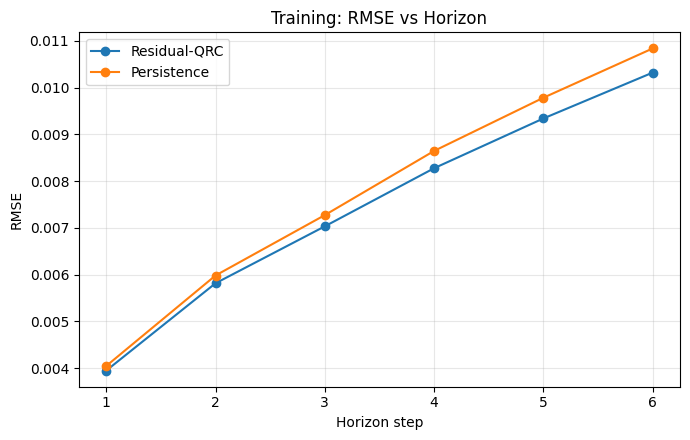

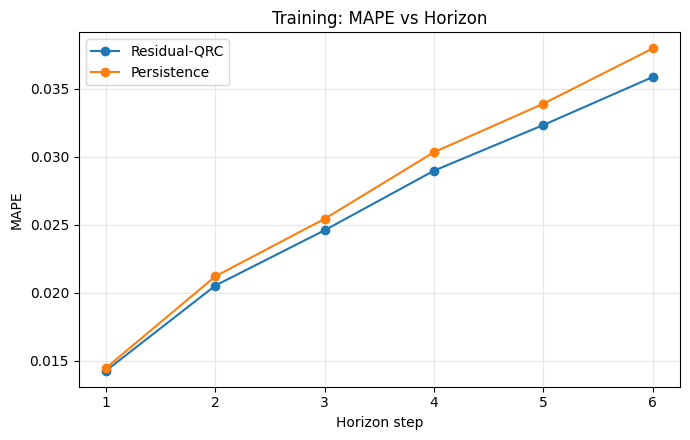

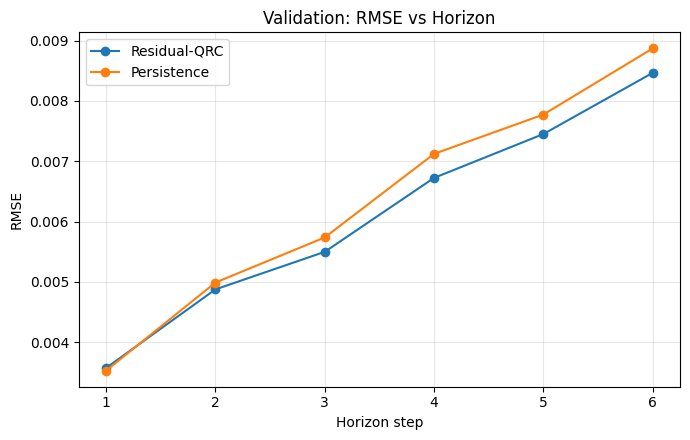

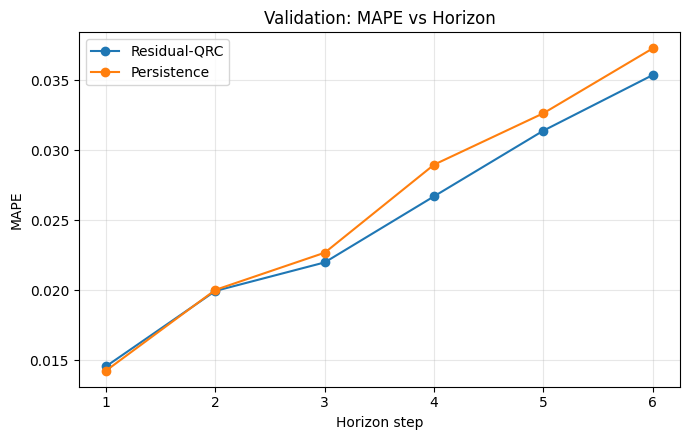

In [353]:
import numpy as np
import matplotlib.pyplot as plt

cfg.fb_strength = 0.0
cfg.ridge_alpha = 0.2

# Residual targets
last_tr, Ytr_res = residual_targets(Xtr_win, Ytr_win)
last_va, Yva_res = residual_targets(Xva_win, Yva_win)

Ytr_res_flat = Ytr_res.reshape(Ytr_res.shape[0], -1)
Yva_res_flat = Yva_res.reshape(Yva_res.shape[0], -1)

R_tr = compute_reservoir_features(Xtr_win, batch_size=64)
R_va = compute_reservoir_features(Xva_win, batch_size=64)

readout = Ridge(alpha=cfg.ridge_alpha, fit_intercept=True)
readout.fit(R_tr, Ytr_res_flat)

Ytr_res_hat = readout.predict(R_tr).astype(np.float32).reshape(Ytr_win.shape)
Ytr_hat = Ytr_res_hat + last_tr[:, None, :]
Yva_res_hat = readout.predict(R_va).astype(np.float32).reshape(Yva_win.shape)
Yva_hat = Yva_res_hat + last_va[:, None, :]

tr_pred_vol = invert_to_vol(Ytr_hat, pca=pca, scaler=scaler, eps=cfg.eps)
va_pred_vol = invert_to_vol(Yva_hat, pca=pca, scaler=scaler, eps=cfg.eps)

# --- helpers ---
def rmse(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.sqrt(np.mean((a - b) ** 2)))

def mape(a: np.ndarray, b: np.ndarray, eps: float = 1e-8) -> float:
    return float(np.mean(np.abs(a - b) / (np.abs(b) + eps)))

def stepwise_metrics(pred_vol: np.ndarray, true_vol: np.ndarray, eps: float):
    """
    pred_vol, true_vol: (N, H, 224)
    returns arrays length H: rmse_by_h, mape_by_h
    """
    H = pred_vol.shape[1]
    rmses = np.zeros(H, dtype=np.float64)
    mapes = np.zeros(H, dtype=np.float64)
    for k in range(H):
        rmses[k] = rmse(pred_vol[:, k, :], true_vol[:, k, :])
        mapes[k] = mape(pred_vol[:, k, :], true_vol[:, k, :], eps=eps)
    return rmses, mapes

def plot_two_curves(h, y_rc, y_pers, ylabel, title):
    plt.figure(figsize=(7, 4.5))
    plt.plot(h, y_rc, marker="o", label="Residual-QRC")
    plt.plot(h, y_pers, marker="o", label="Persistence")
    plt.xlabel("Horizon step")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# -------------------------------------------------------------------
# Assumes you already have these arrays from earlier cells:
#   Residual-RC (vol space):
#     tr_pred_vol, tr_true_vol, va_pred_vol, va_true_vol
#   Persistence (vol space):
#     tr_persist_vol, va_persist_vol
#   cfg.horizon, cfg.eps
# -------------------------------------------------------------------

H = cfg.horizon
h = np.arange(1, H + 1)

# Residual-RC stepwise
rc_tr_rmse, rc_tr_mape = stepwise_metrics(tr_pred_vol, tr_true_vol, eps=cfg.eps)
rc_va_rmse, rc_va_mape = stepwise_metrics(va_pred_vol, va_true_vol, eps=cfg.eps)

# Persistence stepwise
pers_tr_rmse, pers_tr_mape = stepwise_metrics(tr_persist_vol, tr_true_vol, eps=cfg.eps)
pers_va_rmse, pers_va_mape = stepwise_metrics(va_persist_vol, va_true_vol, eps=cfg.eps)

# 1) Training RMSE vs horizon
plot_two_curves(h, rc_tr_rmse, pers_tr_rmse, "RMSE", "Training: RMSE vs Horizon")

# 2) Training MAPE vs horizon
plot_two_curves(h, rc_tr_mape, pers_tr_mape, "MAPE", "Training: MAPE vs Horizon")

# 3) Validation RMSE vs horizon
plot_two_curves(h, rc_va_rmse, pers_va_rmse, "RMSE", "Validation: RMSE vs Horizon")

# 4) Validation MAPE vs horizon
plot_two_curves(h, rc_va_mape, pers_va_mape, "MAPE", "Validation: MAPE vs Horizon")

In [354]:
import numpy as np

cfg.fb_strength = 0.0
cfg.ridge_alpha = 0.2

# Residual targets
last_tr, Ytr_res = residual_targets(Xtr_win, Ytr_win)
last_va, Yva_res = residual_targets(Xva_win, Yva_win)

Ytr_res_flat = Ytr_res.reshape(Ytr_res.shape[0], -1)
Yva_res_flat = Yva_res.reshape(Yva_res.shape[0], -1)

R_tr = compute_reservoir_features(Xtr_win, batch_size=64)
R_va = compute_reservoir_features(Xva_win, batch_size=64)

readout = Ridge(alpha=cfg.ridge_alpha, fit_intercept=True)
readout.fit(R_tr, Ytr_res_flat)

Ytr_res_hat = readout.predict(R_tr).astype(np.float32).reshape(Ytr_win.shape)
Ytr_hat = Ytr_res_hat + last_tr[:, None, :]
Yva_res_hat = readout.predict(R_va).astype(np.float32).reshape(Yva_win.shape)
Yva_hat = Yva_res_hat + last_va[:, None, :]

tr_pred_vol = invert_to_vol(Ytr_hat, pca=pca, scaler=scaler, eps=cfg.eps)
va_pred_vol = invert_to_vol(Yva_hat, pca=pca, scaler=scaler, eps=cfg.eps)

def blend_with_persistence(Y_persist_pca, Y_rc_pca, alpha):
    return Y_persist_pca + alpha * (Y_rc_pca - Y_persist_pca)

alphas = np.linspace(0.0, 1.0, 101)

# assuming you already have:
#   Yva_persist  : (Nva,H,D) in PCA space
#   Yva_hat   : (Nva,H,D) in PCA space (your residual-RC prediction in PCA space)
#   Yva_win      : (Nva,H,D) true in PCA space

best = (1e9, None)
for a in alphas:
    Yblend = blend_with_persistence(Yva_persist, Yva_hat, a)
    pred_vol = invert_to_vol(Yblend, pca=pca, scaler=scaler, eps=cfg.eps)
    true_vol = invert_to_vol(Yva_win, pca=pca, scaler=scaler, eps=cfg.eps)
    v = rmse(pred_vol, true_vol)
    if v < best[0]:
        best = (v, a)

print("best val RMSE:", best[0], "alpha:", best[1])

best val RMSE: 0.006304683384365579 alpha: 0.85


# Prediction of models over test data

In [359]:
cfg.fb_strength = 0.0
cfg.ridge_alpha = 0.2

# Residual targets
last_tr, Ytr_res = residual_targets(Xtr_win, Ytr_win)
last_va, Yva_res = residual_targets(Xva_win, Yva_win)

Ytr_res_flat = Ytr_res.reshape(Ytr_res.shape[0], -1)
Yva_res_flat = Yva_res.reshape(Yva_res.shape[0], -1)

R_tr = compute_reservoir_features(Xtr_win, batch_size=64)
R_va = compute_reservoir_features(Xva_win, batch_size=64)

readout = Ridge(alpha=cfg.ridge_alpha, fit_intercept=True)
readout.fit(R_tr, Ytr_res_flat)

# Old QRC residual model: predict next 6 rows and compare with test.xlsx

import numpy as np
import pandas as pd

required = ['cfg', 'Xva_win', 'compute_reservoir_features', 'readout', 'invert_to_vol', 'pca', 'scaler', 'feature_cols', 'df']
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f'Missing required objects from earlier QRC cells: {missing}')

# 1) Build one inference sample from the last validation window (30 days)
X_last = Z_val[-30:]  # (seq_len, pca_dim)
R_last = compute_reservoir_features(X_last[None, ...], batch_size=1)  # (1, f_dim)

# 2) Predict residuals for horizon=6 in PCA space
y_res_flat = readout.predict(R_last).astype(np.float32)  # (1, horizon*pca_dim)
Y_res_pred = y_res_flat.reshape(1, cfg.horizon, -1)      # (1, 6, pca_dim)

# Residual definition used earlier: Y = residual + last_observed
last_obs = X_last[-1][None, None, :]                     # (1,1,pca_dim)
Y_pred_pca = Y_res_pred + last_obs                       # (1,6,pca_dim)

# 3) Convert prediction back to volatility space
Y_pred_vol = invert_to_vol(Y_pred_pca, pca=pca, scaler=scaler, eps=cfg.eps)[0]  # (6, 224)

# 4) Build predicted dataframe in original HF column order
pred_next6_df = pd.DataFrame(Y_pred_vol, columns=feature_cols)

print('Old QRC predicted next 6 rows:')
display(pred_next6_df)

# 5) Load test.xlsx and compare
try:
    test_df = pd.read_excel('test.xlsx')
except Exception as e:
    raise RuntimeError(
        'Could not read test.xlsx. Install openpyxl in your environment, then rerun. '
        f'Original error: {e}'
    )

if len(test_df) < cfg.horizon:
    raise ValueError(f'test.xlsx has only {len(test_df)} rows; need at least {cfg.horizon}.')

actual6 = test_df.iloc[:cfg.horizon].copy()
missing_cols = [c for c in feature_cols if c not in actual6.columns]
if missing_cols:
    raise ValueError(f'test.xlsx is missing {len(missing_cols)} expected columns. Example: {missing_cols[:5]}')

pred_arr = pred_next6_df[feature_cols].to_numpy(dtype=np.float64)
true_arr = actual6[feature_cols].to_numpy(dtype=np.float64)

rmse_val = float(np.sqrt(np.mean((pred_arr - true_arr) ** 2)))
mape_val = float(100.0 * np.mean(np.abs(pred_arr - true_arr) / (np.abs(true_arr) + 1e-8)))

print('Old QRC next-6 vs test.xlsx')
print('RMSE:', rmse_val)
print('MAPE (%):', mape_val)

rmse_by_step = np.sqrt(np.mean((pred_arr - true_arr) ** 2, axis=1))
mape_by_step = 100.0 * np.mean(np.abs(pred_arr - true_arr) / (np.abs(true_arr) + 1e-8), axis=1)

step_metrics = pd.DataFrame({
    'step_ahead': np.arange(1, cfg.horizon + 1),
    'rmse': rmse_by_step,
    'mape_pct': mape_by_step,
})

print('Per-step metrics:')
display(step_metrics)

Old QRC predicted next 6 rows:


,Tenor : 1; Maturity : 0.0833333333333333,Tenor : 2; Maturity : 0.0833333333333333,Tenor : 3; Maturity : 0.0833333333333333,Tenor : 4; Maturity : 0.0833333333333333,Tenor : 5; Maturity : 0.0833333333333333,Tenor : 6; Maturity : 0.0833333333333333,Tenor : 7; Maturity : 0.0833333333333333,Tenor : 8; Maturity : 0.0833333333333333,Tenor : 9; Maturity : 0.0833333333333333,Tenor : 10; Maturity : 0.0833333333333333,...,Tenor : 5; Maturity : 30,Tenor : 6; Maturity : 30,Tenor : 7; Maturity : 30,Tenor : 8; Maturity : 30,Tenor : 9; Maturity : 30,Tenor : 10; Maturity : 30,Tenor : 15; Maturity : 30,Tenor : 20; Maturity : 30,Tenor : 25; Maturity : 30,Tenor : 30; Maturity : 30
0,0.023593,0.031821,0.033844,0.035489,0.036057,0.035498,0.035132,0.034827,0.035105,0.034506,...,0.343229,0.341387,0.343684,0.337352,0.338932,0.335890,0.359064,0.374381,0.354523,0.344210
1,0.023565,0.031810,0.033822,0.035448,0.036008,0.035439,0.035057,0.034745,0.035015,0.034411,...,0.342389,0.340542,0.342842,0.336491,0.338064,0.335007,0.358305,0.373696,0.353859,0.343622
2,0.023182,0.031510,0.033539,0.035159,0.035737,0.035167,0.034774,0.034460,0.034721,0.034116,...,0.339738,0.337879,0.340192,0.333809,0.335386,0.332325,0.355795,0.371224,0.351684,0.341742
3,0.023284,0.031651,0.033663,0.035249,0.035804,0.035209,0.034782,0.034456,0.034703,0.034085,...,0.339076,0.337217,0.339533,0.333137,0.334705,0.331629,0.355206,0.370637,0.351216,0.341322
4,0.023077,0.031519,0.033543,0.035130,0.035707,0.035107,0.034673,0.034343,0.034582,0.033957,...,0.336572,0.334702,0.337047,0.330642,0.332249,0.329222,0.352819,0.368220,0.349124,0.339506
5,0.022981,0.031380,0.033422,0.035038,0.035638,0.035064,0.034662,0.034349,0.034602,0.033992,...,0.337356,0.335496,0.337860,0.331470,0.333110,0.330117,0.353592,0.368926,0.349713,0.340034


Old QRC next-6 vs test.xlsx
RMSE: 0.014570631925232032
MAPE (%): 6.186143362814884
Per-step metrics:


,step_ahead,rmse,mape_pct
0,1,0.002481,1.130249
1,2,0.007323,3.905353
2,3,0.010386,5.378857
3,4,0.014328,7.158944
4,5,0.022781,10.440053
5,6,0.019542,9.103404


# Prediction of models over test data

In [361]:
# Persistence model: predict next 6 rows and compare with test.xlsx

import numpy as np
import pandas as pd

required = ['cfg', 'invert_to_vol', 'pca', 'scaler', 'df']
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f'Missing required objects from earlier cells: {missing}')

# Use last 30 days from validation tail in PCA space
if 'Z_val' in globals():
    X_last = Z_val[-cfg.seq_len:]  # (seq_len, pca_dim)
elif 'Xva_win' in globals():
    X_last = Xva_win[-1]           # (seq_len, pca_dim)
else:
    raise RuntimeError('Need either Z_val or Xva_win defined from previous QRC preprocessing cells.')

# Persistence forecast in PCA space: repeat last observed point for all 6 steps
last_obs = X_last[-1]  # (pca_dim,)
Y_persist_pca = np.repeat(last_obs[None, None, :], cfg.horizon, axis=1).astype(np.float32)  # (1,6,D)

# Convert to volatility space
Y_persist_vol = invert_to_vol(Y_persist_pca, pca=pca, scaler=scaler, eps=cfg.eps)[0]  # (6,224)

feature_cols = [c for c in df.columns if c != 'Date']

persist_next6_df = pd.DataFrame(Y_persist_vol, columns=feature_cols)

print('Persistence predicted next 6 rows:')
display(persist_next6_df)

# Compare against test.xlsx
try:
    test_df = pd.read_excel('test.xlsx')
except Exception as e:
    raise RuntimeError(
        'Could not read test.xlsx. Install openpyxl in your environment, then rerun. '
        f'Original error: {e}'
    )

if len(test_df) < cfg.horizon:
    raise ValueError(f'test.xlsx has only {len(test_df)} rows; need at least {cfg.horizon}.')

actual6 = test_df.iloc[:cfg.horizon].copy()
missing_cols = [c for c in feature_cols if c not in actual6.columns]
if missing_cols:
    raise ValueError(f'test.xlsx is missing {len(missing_cols)} expected columns. Example: {missing_cols[:5]}')

pred_arr = persist_next6_df[feature_cols].to_numpy(dtype=np.float64)
true_arr = actual6[feature_cols].to_numpy(dtype=np.float64)

rmse_val = float(np.sqrt(np.mean((pred_arr - true_arr) ** 2)))
mape_val = float(100.0 * np.mean(np.abs(pred_arr - true_arr) / (np.abs(true_arr) + 1e-8)))

print('Persistence next-6 vs test.xlsx')
print('RMSE:', rmse_val)
print('MAPE (%):', mape_val)

rmse_by_step = np.sqrt(np.mean((pred_arr - true_arr) ** 2, axis=1))
mape_by_step = 100.0 * np.mean(np.abs(pred_arr - true_arr) / (np.abs(true_arr) + 1e-8), axis=1)

step_metrics = pd.DataFrame({
    'step_ahead': np.arange(1, cfg.horizon + 1),
    'rmse': rmse_by_step,
    'mape_pct': mape_by_step,
})

print('Per-step metrics:')
display(step_metrics)



Persistence predicted next 6 rows:


,Tenor : 1; Maturity : 0.0833333333333333,Tenor : 2; Maturity : 0.0833333333333333,Tenor : 3; Maturity : 0.0833333333333333,Tenor : 4; Maturity : 0.0833333333333333,Tenor : 5; Maturity : 0.0833333333333333,Tenor : 6; Maturity : 0.0833333333333333,Tenor : 7; Maturity : 0.0833333333333333,Tenor : 8; Maturity : 0.0833333333333333,Tenor : 9; Maturity : 0.0833333333333333,Tenor : 10; Maturity : 0.0833333333333333,...,Tenor : 5; Maturity : 30,Tenor : 6; Maturity : 30,Tenor : 7; Maturity : 30,Tenor : 8; Maturity : 30,Tenor : 9; Maturity : 30,Tenor : 10; Maturity : 30,Tenor : 15; Maturity : 30,Tenor : 20; Maturity : 30,Tenor : 25; Maturity : 30,Tenor : 30; Maturity : 30
0,0.023542,0.031677,0.033678,0.035316,0.035875,0.035327,0.034974,0.034672,0.034959,0.034372,...,0.343968,0.342117,0.344366,0.338039,0.339575,0.336494,0.359618,0.374937,0.355129,0.344858
1,0.023542,0.031677,0.033678,0.035316,0.035875,0.035327,0.034974,0.034672,0.034959,0.034372,...,0.343968,0.342117,0.344366,0.338039,0.339575,0.336494,0.359618,0.374937,0.355129,0.344858
2,0.023542,0.031677,0.033678,0.035316,0.035875,0.035327,0.034974,0.034672,0.034959,0.034372,...,0.343968,0.342117,0.344366,0.338039,0.339575,0.336494,0.359618,0.374937,0.355129,0.344858
3,0.023542,0.031677,0.033678,0.035316,0.035875,0.035327,0.034974,0.034672,0.034959,0.034372,...,0.343968,0.342117,0.344366,0.338039,0.339575,0.336494,0.359618,0.374937,0.355129,0.344858
4,0.023542,0.031677,0.033678,0.035316,0.035875,0.035327,0.034974,0.034672,0.034959,0.034372,...,0.343968,0.342117,0.344366,0.338039,0.339575,0.336494,0.359618,0.374937,0.355129,0.344858
5,0.023542,0.031677,0.033678,0.035316,0.035875,0.035327,0.034974,0.034672,0.034959,0.034372,...,0.343968,0.342117,0.344366,0.338039,0.339575,0.336494,0.359618,0.374937,0.355129,0.344858


Persistence next-6 vs test.xlsx
RMSE: 0.012605256389860889
MAPE (%): 5.623593233900503
Per-step metrics:


,step_ahead,rmse,mape_pct
0,1,0.002468,1.264063
1,2,0.006927,3.818087
2,3,0.008702,4.711851
3,4,0.012272,6.391294
4,5,0.019677,9.374138
5,6,0.016904,8.182127
